In [1]:
# Reload modules automatically.
%load_ext autoreload
%autoreload 2

## 1. Load and preprocess data.

### 1.0 Load necessary global variables and saved data

In [20]:
import yaml
import pickle
import numpy as np

# reload dict data from pickle files
# with open('raw_coord_dict.pkl', 'rb') as f:
#     raw_coord_dict = pickle.load(f)
# with open('raw_com_dict.pkl', 'rb') as f:
#     raw_com_dict = pickle.load(f)
# with open('corr_coord_dict.pkl', 'rb') as f:
#     corr_coord_dict = pickle.load(f)
# with open('smth_coord_dict.pkl', 'rb') as f:
#     smth_coord_dict = pickle.load(f)
# with open('simp_com_dict.pkl', 'rb') as f:
#     simp_com_dict = pickle.load(f)
with open('coord_dict.pkl', 'rb') as f:
    coord_dict = pickle.load(f)

with open('nest_tuples_dict.pkl', 'rb') as f:
    nest_tuples_dict = pickle.load(f)
with open('nest_series_dict.pkl', 'rb') as f:
    nest_series_dict = pickle.load(f)
with open('trig_tuples_dict.pkl', 'rb') as f:
    trig_tuples_dict = pickle.load(f)
with open('trig_series_dict.pkl', 'rb') as f:
    trig_series_dict = pickle.load(f)

with open('lsf_dict.pkl', 'rb') as f:
    lsf_dict = pickle.load(f)

# with open('raw_syl_dict.pkl', 'rb') as f:
#     raw_syl_dict = pickle.load(f)
with open('bhvr_kpms_dict.pkl', 'rb') as f:
    bhvr_kpms_dict = pickle.load(f)
# with open('bhvr_kpms_dict_refined.pkl', 'rb') as f:
#     bhvr_kpms_dict_refined = pickle.load(f)
with open('bhvr_kpms_dict_smoothed.pkl', 'rb') as f:
    bhvr_kpms_dict_smoothed = pickle.load(f)
with open('bhvr_tuples_dict.pkl', 'rb') as f:
    bhvr_tuples_dict = pickle.load(f)
with open('bhvr_series_dict.pkl', 'rb') as f:
    bhvr_series_dict = pickle.load(f)


# Reload config data from yaml file
with open("analyze_data_3d_cfg.yaml", "r") as f:
    cfg = yaml.safe_load(f)

fps = cfg["fps"]
# joint_names = cfg["joint_names"]
joint_names = cfg['simp_joint_names']
limb_orders = cfg["limb_orders"]
limb_combos = cfg["limb_combos"]
joint_creds = cfg["joint_creds"]
# skel_conns = [tuple(pair) for pair in cfg["skel_conns"]]
skel_conns = [tuple(pair) for pair in cfg["simp_skel_conns"]]
# c_maps = cfg["c_maps"]
c_maps = cfg["simp_c_maps"]
bhvr_map = cfg["bhvr_map"]

# joint_exclude = cfg["joint_exclude"]
# joint_used = [j for j in joint_names if j not in joint_exclude]

### 1.1 Get predicted coordinate data

#### 1.1.1 Get raw coordinate data from .mat files

In [3]:
import pickle
from analyze_data_3d_utils.DataLoader import load_coord_data

mat_dir = '/home/gxj/Desktop/Synology25/dannce_results/'
raw_coord_dict = load_coord_data(mat_dir, pred_type='pred', check_sess=True)
with open('raw_coord_dict.pkl', 'wb') as f:
    pickle.dump(raw_coord_dict, f)

raw_com_dict = load_coord_data(mat_dir, pred_type='com', check_sess=True)
with open('raw_com_dict.pkl', 'wb') as f:
    pickle.dump(raw_com_dict, f)

Number of sessions: 205
Number of sessions: 205
['G1M1D1', 'G1M1D2', 'G1M1D3', 'G1M1D4', 'G1M1D5']
['G1M2D1', 'G1M2D2', 'G1M2D3', 'G1M2D4', 'G1M2D5']
['G1M3D1', 'G1M3D2', 'G1M3D3', 'G1M3D4', 'G1M3D5']
['G1M4D1', 'G1M4D2', 'G1M4D3', 'G1M4D4', 'G1M4D5']
['G1M5D1', 'G1M5D2', 'G1M5D3', 'G1M5D4', 'G1M5D5']
['G1M6D1', 'G1M6D2', 'G1M6D3', 'G1M6D4', 'G1M6D5']
['G1M7D1', 'G1M7D2', 'G1M7D3', 'G1M7D4', 'G1M7D5']
['G2M1D1', 'G2M1D2', 'G2M1D3', 'G2M1D4', 'G2M1D5']
['G2M2D1', 'G2M2D2', 'G2M2D3', 'G2M2D4', 'G2M2D5']
['G2M3D1', 'G2M3D2', 'G2M3D3', 'G2M3D4', 'G2M3D5']
['G2M4D1', 'G2M4D2', 'G2M4D3', 'G2M4D4', 'G2M4D5']
['G2M5D1', 'G2M5D2', 'G2M5D3', 'G2M5D4', 'G2M5D5']
['G2M6D1', 'G2M6D2', 'G2M6D3', 'G2M6D4', 'G2M6D5']
['G3M1D1', 'G3M1D2', 'G3M1D3', 'G3M1D4', 'G3M1D5']
['G3M2D1', 'G3M2D2', 'G3M2D3', 'G3M2D4', 'G3M2D5']
['G3M3D1', 'G3M3D2', 'G3M3D3', 'G3M3D4', 'G3M3D5']
['G3M4D1', 'G3M4D2', 'G3M4D3', 'G3M4D4', 'G3M4D5']
['G3M5D1', 'G3M5D2', 'G3M5D3', 'G3M5D4', 'G3M5D5']
['G3M6D1', 'G3M6D2', 'G3M6D3', 'G3

#### 1.1.2 Remove outliers and interpolation

In [4]:
import pickle
from analyze_data_3d_utils.DataProcessor import find_medoid_distance_outliers, find_RULE_outliers, interpolate_keypoints

corr_coord_dict = {}
for sess_id in raw_coord_dict.keys():
    raw_coords = raw_coord_dict[sess_id].copy()
    outliers = find_medoid_distance_outliers(raw_coords, outlier_scale_factor=6)
    outliers_ = find_RULE_outliers(
        raw_coords, joint_names, limb_orders, skel_conns, joint_creds, 
        prev_outliers=outliers, outlier_scale_factors={'velocity': 5, 'angle': 5, 'displacement': 5})
    interpolated_dict = interpolate_keypoints(raw_coords, outliers_['mask'])
    corr_coord_dict[sess_id] = interpolated_dict

with open('corr_coord_dict.pkl', 'wb') as f:
    pickle.dump(corr_coord_dict, f)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


#### 1.1.3 Smooth coordinate data

In [5]:
import pickle
from analyze_data_3d_utils.DataProcessor import smooth_data

smth_coord_dict = {}
for sess_id in corr_coord_dict.keys():
    coords = corr_coord_dict[sess_id]
    smoothed = smooth_data(coords, method='savgol', window_length=5, polyorder=3)    
    smth_coord_dict[sess_id] = smoothed

with open('smth_coord_dict.pkl', 'wb') as f:
    pickle.dump(smth_coord_dict, f)

print(smth_coord_dict[list(smth_coord_dict.keys())[0]].shape)

(60313, 21, 3)


#### 1.1.4 Simplify coordinate data。

In [6]:
import pickle
from analyze_data_3d_utils.DataProcessor import simplify_coord_dict

simp_coord_dict, simp_joint_names = simplify_coord_dict(
    smth_coord_dict, joint_names, limb_combos
)
with open('simp_coord_dict.pkl', 'wb') as f:
    pickle.dump(simp_coord_dict, f)
print(simp_coord_dict[list(simp_coord_dict.keys())[0]].shape)


(60313, 15, 3)


In [7]:
import pickle

coord_dict = simp_coord_dict
with open('coord_dict.pkl', 'wb') as f:
    pickle.dump(coord_dict, f)

In [5]:
from analyze_data_3d_utils.SkelVisualizer import draw_mean_skeleton

# visualize mean skeleton to check correction effect.
# all_coords = np.concatenate(list(raw_coord_dict.values()), axis=0)
draw_mean_skeleton(coord_dict['G1M1D1'], joint_names, skel_conns)
# draw_mean_skeleton(raw_coord_dict['G1M1D1'], joint_names, skel_conns)

### 1.2 Get the predicted behavior data `bhvr_dict`.

#### 1.2.1 Get syllabel data `raw_syl_dict` from `results.h5` file.

In [55]:
import pickle
import numpy as np
from analyze_data_3d_utils.DataLoader import load_syl_data
syl_h5_path = '/home/gxj/Desktop/gxj/kpms_project/state-100_kappa-1e6/results.h5'
syl_dir =  '/home/gxj/Desktop/gxj/kpms_project/state-100_kappa-1e6/results'
prefix = '-home-gxj-Desktop-Synology25-dannce_results-'
suffix = '-save_data_AVG0.csv'

raw_syl_dict = load_syl_data(syl_dir, prefix, suffix, check_sess=True)
with open('raw_syl_dict.pkl', 'wb') as f:
    pickle.dump(raw_syl_dict, f)

# Data structure:
# syl_dict = {'ses_id': np.array of shape (n_frames, ), ...}, where each element is an integer syllable label.

Number of sessions: 205
['G1M1D1', 'G1M1D2', 'G1M1D3', 'G1M1D4', 'G1M1D5']
['G1M2D1', 'G1M2D2', 'G1M2D3', 'G1M2D4', 'G1M2D5']
['G1M3D1', 'G1M3D2', 'G1M3D3', 'G1M3D4', 'G1M3D5']
['G1M4D1', 'G1M4D2', 'G1M4D3', 'G1M4D4', 'G1M4D5']
['G1M5D1', 'G1M5D2', 'G1M5D3', 'G1M5D4', 'G1M5D5']
['G1M6D1', 'G1M6D2', 'G1M6D3', 'G1M6D4', 'G1M6D5']
['G1M7D1', 'G1M7D2', 'G1M7D3', 'G1M7D4', 'G1M7D5']
['G2M1D1', 'G2M1D2', 'G2M1D3', 'G2M1D4', 'G2M1D5']
['G2M2D1', 'G2M2D2', 'G2M2D3', 'G2M2D4', 'G2M2D5']
['G2M3D1', 'G2M3D2', 'G2M3D3', 'G2M3D4', 'G2M3D5']
['G2M4D1', 'G2M4D2', 'G2M4D3', 'G2M4D4', 'G2M4D5']
['G2M5D1', 'G2M5D2', 'G2M5D3', 'G2M5D4', 'G2M5D5']
['G2M6D1', 'G2M6D2', 'G2M6D3', 'G2M6D4', 'G2M6D5']
['G3M1D1', 'G3M1D2', 'G3M1D3', 'G3M1D4', 'G3M1D5']
['G3M2D1', 'G3M2D2', 'G3M2D3', 'G3M2D4', 'G3M2D5']
['G3M3D1', 'G3M3D2', 'G3M3D3', 'G3M3D4', 'G3M3D5']
['G3M4D1', 'G3M4D2', 'G3M4D3', 'G3M4D4', 'G3M4D5']
['G3M5D1', 'G3M5D2', 'G3M5D3', 'G3M5D4', 'G3M5D5']
['G3M6D1', 'G3M6D2', 'G3M6D3', 'G3M6D4', 'G3M6D5']
['G3M7D

In [ ]:
# Save raw_syl_dict to check in deepethogram.
from analyze_data_3d_utils.DataProcessor import convert_bhvr_kpms2series, save_bhvr_dicts

syl_series_dict = convert_bhvr_kpms2series(raw_syl_dict)
save_folder = '/home/gxj/Desktop/gxj/code/lst_3d_code/bhvr_series_output'
save_bhvr_dicts(syl_series_dict, save_folder, save_format='csv', file_prefix='state-100_kappa-1e6_')

In [17]:
# Find syllabel indexes.
sess_id = 'G3M1D1'
syllable_num = 32
idx = np.where(raw_syl_dict[sess_id] == syllable_num)[0]
print(idx.tolist())

[]


#### 1.2.2 Map `syl_dict` to `bhvr_dict` based on `bhvr_map`.

In [5]:
import numpy as np
import pickle
from analyze_data_3d_utils.DataProcessor import map_syllabel_to_behavior

# Map syllable labels to behavior names.
bhvr_kpms_dict = map_syllabel_to_behavior(raw_syl_dict, bhvr_map)

# Save to pickle file.
with open('bhvr_kpms_dict.pkl', 'wb') as f:
    pickle.dump(bhvr_kpms_dict, f)

# Print statistics for verification.
print(f"\nExample session {list(bhvr_kpms_dict.keys())[0]}:")
unique_bhvr, counts = np.unique(bhvr_kpms_dict[list(bhvr_kpms_dict.keys())[0]], return_counts=True)
total = len(bhvr_kpms_dict[list(bhvr_kpms_dict.keys())[0]])
for bhvr, count in zip(unique_bhvr, counts):
    print(f"  {bhvr}: {count} frames ({count/total:.2%})")


Example session G1M1D1:
  body_grooming: 142 frames (0.24%)
  body_grooming-complete_rearing-onnest: 389 frames (0.64%)
  complete_rearing: 4368 frames (7.24%)
  complete_rearing-face_grooming: 951 frames (1.58%)
  face_grooming: 1142 frames (1.89%)
  face_grooming-complete_rearing-onnest: 22 frames (0.04%)
  face_grooming-immobile: 480 frames (0.80%)
  genital_grooming-complete_rearing-onnest: 365 frames (0.61%)
  head_raising: 4744 frames (7.87%)
  immobile: 6783 frames (11.25%)
  incomplete_rearing: 8595 frames (14.25%)
  incomplete_rearing-onnest: 911 frames (1.51%)
  incomplete_rearing_onnest: 69 frames (0.11%)
  other: 2 frames (0.00%)
  rearing-onnest: 176 frames (0.29%)
  slightly_mobile: 193 frames (0.32%)
  sniffing: 11687 frames (19.38%)
  sniffing-face_grooming_onnest: 14 frames (0.02%)
  sniffing-onnest: 1422 frames (2.36%)
  trotting: 676 frames (1.12%)
  walking: 17182 frames (28.49%)


#### 1.2.3 Create `nest_series_dict` to store nest zone information

In [6]:
import pickle
import pandas as pd
from matplotlib.path import Path
from analyze_data_3d_utils.DataProcessor import convert_bhvr_series2tuples, filter_short_states

nest_coord = np.array([[0, 0], [0, 22.65], [16.23, 22.65], [16.23, 0]])
nest_path = Path(nest_coord)

nest_series_dict = {}
for sess_id in coord_dict.keys():
    nest_series_dict[sess_id] = {}
    coord_data = coord_dict[sess_id]
    
    xy = coord_data[:, joint_names.index('SpineM'), :2]
    in_nest = nest_path.contains_points(xy)
    
    # Create index from coordinate data length.
    nest_series = pd.Series(
        in_nest,
        index=np.arange(len(coord_data)),
        name='nest'
    )

    # Filter short state changes (< 10 frames) due to jitter.
    nest_series_filtered = filter_short_states(nest_series, min_frames=10)
    
    nest_series_dict[sess_id]['nest'] = nest_series_filtered

nest_tuples_dict = convert_bhvr_series2tuples(nest_series_dict)

# Save to pickle file.
with open('nest_series_dict.pkl', 'wb') as f:
    pickle.dump(nest_series_dict, f)
with open('nest_tuples_dict.pkl', 'wb') as f:
    pickle.dump(nest_tuples_dict, f)

#### 1.2.4 Create `trig_series_dict` to store trigger zone information.

In [8]:
import pickle
import pandas as pd
from matplotlib.path import Path
from analyze_data_3d_utils.DataProcessor import convert_bhvr_series2tuples, filter_short_states

trig_coord = np.array([[0, 19.5], [0, 50], [50, 50], [50, 19.5]])
trig_path = Path(trig_coord)

trig_series_dict = {}
for sess_id in coord_dict.keys():
    trig_series_dict[sess_id] = {}
    coord_data = coord_dict[sess_id]
    
    xy = coord_data[:, joint_names.index('SpineM'), :2]
    in_trig = trig_path.contains_points(xy)
    
    # Create index from coordinate data length.
    trig_series = pd.Series(
        in_trig,
        index=np.arange(len(coord_data)),
        name='trig'
    )

    # Filter short state changes (< 10 frames) due to jitter.
    trig_series_filtered = filter_short_states(trig_series, min_frames=10)
    
    trig_series_dict[sess_id]['trig'] = trig_series_filtered

trig_tuples_dict = convert_bhvr_series2tuples(trig_series_dict)

# Save to pickle file.
with open('trig_series_dict.pkl', 'wb') as f:
    pickle.dump(trig_series_dict, f)
with open('trig_tuples_dict.pkl', 'wb') as f:
    pickle.dump(trig_tuples_dict, f)

#### 1.2.5 Refine `bhvr_kpms_dict`.

In [4]:
import numpy as np
from collections import defaultdict

def refine_bhvr_with_kinematics(bhvr_dict, coord_dict, nest_series_dict, simp_joint_names, fps=20, check=False):
    """
    Refine behavior labels using kinematic features and nest zone information.
    
    Args:
        bhvr_dict: dict of behavior label arrays
        coord_dict: dict of coordinate arrays (n_frames, n_joints, 3)
        nest_series_dict: dict of nest zone Series
        simp_joint_names: list of simplified joint names
        fps: frames per second
        check: if True, print replacement statistics for each session
    
    Returns:
        refined behavior dict
    """
    
    def _apply_onnest_rule(labels, coords, in_nest, joint_names, changes_dict=None):
        """Rule 1: Determine onnest status based on hindlimb height in nest.
        New naming: behaviors separated by '-'
        Example: 'body-grooming-complete-rearing-onnest'
        """
        # Get hindlimb joint indices
        hindlimb_joints = ['TailB', 'HindpawR', 'HindpawL', 'KneeR', 'KneeL']
        hindlimb_indices = [joint_names.index(j) for j in hindlimb_joints if j in joint_names]
        
        if len(hindlimb_indices) == 0:
            return labels
        
        # Calculate median z-coordinate of hindlimbs
        hindlimb_z = coords[:, hindlimb_indices, 2]
        median_z = np.median(hindlimb_z, axis=1)
        
        refined = labels.copy()
        for i, lbl in enumerate(labels):
            old_lbl = lbl
            
            if in_nest[i]:
                # In nest: validate onnest status
                if 'onnest' in lbl:
                    # Already has onnest marker, check if valid (height > 2cm)
                    if median_z[i] <= 2.0:
                        # Not high enough, remove entire onnest part
                        parts = lbl.split('-')
                        filtered_parts = [p for p in parts if 'onnest' not in p]
                        refined[i] = '-'.join(filtered_parts) if filtered_parts else 'other'
                    else:
                        # High enough, truly onnest - keep only 'onnest' label
                        refined[i] = 'onnest'
            else:
                # Not in nest: remove any onnest parts
                if 'onnest' in lbl:
                    parts = lbl.split('-')
                    filtered_parts = [p for p in parts if 'onnest' not in p]
                    refined[i] = '-'.join(filtered_parts) if filtered_parts else 'other'
            
            # Clean up edge cases
            if refined[i] in ['', '-', 'other']:
                refined[i] = 'other'
            
            if changes_dict is not None and refined[i] != old_lbl:
                changes_dict[f"{old_lbl} -> {refined[i]}"] += 1
        
        return refined
    
    def _apply_running_rule(labels, coords, fps, joint_names, min_duration_frames=5, changes_dict=None):
        """Rule 2: Replace with 'running' if median speed > 25 cm/s for at least min_duration_frames.
        
        Args:
            joint_names: list of joint names to get indices
            min_duration_frames: Minimum number of consecutive frames exceeding speed threshold
                                to be classified as running (default: 5 frames = 0.25s at 20fps)
        """
        # Calculate speed for all joints (xy plane only, exclude z)
        n_frames, n_joints, n_dims = coords.shape
        velocities = np.diff(coords[:, :, :2], axis=0, prepend=coords[[0], :, :2])
        speeds = np.linalg.norm(velocities, axis=2) * fps  # (n_frames, n_joints)
        
        # Select specific joints for speed calculation
        trunk_joints = ['EarL', 'EarR', 'Snout', 'SpineF', 'SpineM', 'TailB']
        speed_joint_indices = [joint_names.index(j) for j in trunk_joints if j in joint_names]
        
        # Minimum speed across selected joints (all joints must exceed threshold)
        if len(speed_joint_indices) > 0:
            min_speed = np.min(speeds[:, speed_joint_indices], axis=1)
        else:
            # Fallback to all joints if selected joints not found
            min_speed = np.min(speeds, axis=1)
        
        # Find frames exceeding speed threshold (all trunk joints must exceed)
        high_speed_mask = min_speed > 25
        
        # Filter out short bursts: only keep segments with >= min_duration_frames consecutive high-speed frames
        running_mask = np.zeros(n_frames, dtype=bool)
        i = 0
        while i < n_frames:
            if high_speed_mask[i]:
                # Found start of a high-speed segment
                segment_start = i
                segment_end = i
                # Find end of consecutive high-speed frames
                while segment_end < n_frames and high_speed_mask[segment_end]:
                    segment_end += 1
                segment_length = segment_end - segment_start
                
                # Only mark as running if segment is long enough
                if segment_length >= min_duration_frames:
                    running_mask[segment_start:segment_end] = True
                
                i = segment_end
            else:
                i += 1
        
        # Apply running label to filtered frames
        refined = labels.copy()
        for i in range(n_frames):
            if running_mask[i]:
                old_lbl = refined[i]
                refined[i] = 'running'
                if changes_dict is not None and refined[i] != old_lbl:
                    changes_dict[f"{old_lbl} -> {refined[i]}"] += 1
        
        return refined
    
    def _apply_rearing_rule(labels, coords, joint_names, changes_dict=None):
        """Rule 3: Keep rearing parts if head is raised, or remove if not.
        New naming: behaviors separated by '-'
        Example: 'body-grooming-complete-rearing-onnest' -> 'complete-rearing' if head raised, else remove rearing
        Note: Single rearing types (e.g., 'complete_rearing', 'incomplete_rearing') are not validated.
        """
        # Get joint indices
        try:
            snout_idx = joint_names.index('Snout')
            earr_idx = joint_names.index('EarR')
            earl_idx = joint_names.index('EarL')
            spinef_idx = joint_names.index('SpineF')
            spinem_idx = joint_names.index('SpineM')
        except ValueError:
            return labels
        
        # Calculate median z of head points (4 points: Snout, EarR, EarL, SpineF)
        head_z = coords[:, [snout_idx, earr_idx, earl_idx, spinef_idx], 2]
        median_head_z = np.median(head_z, axis=1)
        spine_z = coords[:, spinem_idx, 2]
        
        refined = labels.copy()
        for i, lbl in enumerate(labels):
            if 'rearing' in lbl:
                # Skip validation for single rearing types
                parts = lbl.split('-')
                if len(parts) == 1:
                    # Single label like 'complete_rearing' or 'incomplete_rearing', no validation needed
                    continue
                
                old_lbl = lbl
                # Check if head is raised for composite labels
                if median_head_z[i] > spine_z[i] + 0.5:
                    # Head is raised, truly rearing - keep only rearing-related parts
                    rearing_parts = [p for p in parts if 'rearing' in p]
                    refined[i] = '-'.join(rearing_parts) if rearing_parts else 'rearing'
                else:
                    # Head not raised, remove rearing parts
                    filtered_parts = [p for p in parts if 'rearing' not in p]
                    refined[i] = '-'.join(filtered_parts) if filtered_parts else 'other'
                
                if changes_dict is not None and refined[i] != old_lbl:
                    changes_dict[f"{old_lbl} -> {refined[i]}"] += 1
        
        return refined
    
    def _apply_freezing_rule(labels, coords, fps, joint_names, changes_dict=None):
        """Rule 4: Validate immobile labels based on speed (exclude TailM).
        If truly immobile (speed < 0.46 cm/s), simplify to 'immobile'.
        If not truly immobile (speed >= 0.46 cm/s), remove immobile parts.
        """
        # Calculate speed for all joints (exclude TailM)
        n_frames, n_joints, n_dims = coords.shape
        
        # Get indices to exclude TailM
        if 'TailM' in joint_names:
            tailm_idx = joint_names.index('TailM')
            joint_indices = [i for i in range(n_joints) if i != tailm_idx]
        else:
            joint_indices = list(range(n_joints))
        
        velocities = np.diff(coords[:, joint_indices, :2], axis=0, prepend=coords[0:1, joint_indices, :2])
        speeds = np.linalg.norm(velocities, axis=2) * fps  # (n_frames, n_joints_filtered)
        
        # Max speed across all joints (all should be < threshold)
        max_speed = np.max(speeds, axis=1)
        
        refined = labels.copy()
        for i, lbl in enumerate(labels):
            old_lbl = lbl
            if 'immobile' in lbl:
                if max_speed[i] < 0.5:
                    # Truly immobile, simplify to just 'immobile'
                    refined[i] = 'immobile'
                else:
                    # Not truly immobile, remove immobile parts
                    parts = lbl.split('-')
                    filtered_parts = [p for p in parts if 'immobile' not in p]
                    refined[i] = '-'.join(filtered_parts) if filtered_parts else 'immobile'
            else:
                # Label does not contain 'immobile'
                if max_speed[i] < 0.5:
                    # Actually immobile, change to 'slightly_mobile'
                    refined[i] = 'slightly_mobile'
            
            if changes_dict is not None and refined[i] != old_lbl:
                changes_dict[f"{old_lbl} -> {refined[i]}"] += 1
        
        return refined
    
    # Apply all rules sequentially
    refined_dict = {}
    for sess_id, labels in bhvr_dict.items():
        coords = coord_dict[sess_id]
        in_nest = nest_series_dict[sess_id]['nest'].values.astype(bool)
        
        labels_arr = np.array(labels, dtype=object)
        
        # Track changes if check=True
        changes = defaultdict(int) if check else None
        
        # Apply rules in order
        running_thr = 5  # frames
        labels_arr = _apply_onnest_rule(labels_arr, coords, in_nest, simp_joint_names, changes)
        labels_arr = _apply_running_rule(labels_arr, coords, fps, simp_joint_names, running_thr, changes)
        labels_arr = _apply_rearing_rule(labels_arr, coords, simp_joint_names, changes)
        labels_arr = _apply_freezing_rule(labels_arr, coords, fps, simp_joint_names, changes)
        
        refined_dict[sess_id] = labels_arr
        
        # Print changes for this session
        if check and changes:
            print(f"\n{sess_id}:")
            for change, count in sorted(changes.items()):
                print(f"  {change}: {count} frames")
    
    return refined_dict


# Apply refinement
bhvr_kpms_dict_refined = refine_bhvr_with_kinematics(
    bhvr_kpms_dict,
    coord_dict,
    nest_series_dict,
    joint_names,
    fps=fps,
    check=True)

# Save refined behavior dict
with open('bhvr_kpms_dict_refined.pkl', 'wb') as f:
    pickle.dump(bhvr_kpms_dict_refined, f)


G1M1D1:
  body_grooming-complete_rearing -> body_grooming: 179 frames
  body_grooming-complete_rearing -> complete_rearing: 95 frames
  body_grooming-complete_rearing-onnest -> body_grooming-complete_rearing: 274 frames
  body_grooming-complete_rearing-onnest -> onnest: 115 frames
  complete_rearing -> running: 32 frames
  complete_rearing-face_grooming -> complete_rearing: 578 frames
  complete_rearing-face_grooming -> face_grooming: 373 frames
  face_grooming-complete_rearing -> complete_rearing: 2 frames
  face_grooming-complete_rearing -> face_grooming: 7 frames
  face_grooming-complete_rearing-onnest -> face_grooming-complete_rearing: 9 frames
  face_grooming-complete_rearing-onnest -> onnest: 13 frames
  face_grooming-immobile -> face_grooming: 479 frames
  face_grooming-immobile -> immobile: 1 frames
  genital_grooming-complete_rearing -> complete_rearing: 52 frames
  genital_grooming-complete_rearing -> genital_grooming: 57 frames
  genital_grooming-complete_rearing -> running

#### 1.2.5.1 Smooth behavior sequences using modal filter

In [7]:
from collections import Counter

def modal_filter(labels, window_size=5):
    """
    Apply modal filter (mode/majority voting in sliding window) to behavior sequence.
    Uses the most frequent label in each window (众数滤波).
    
    Args:
        labels: 1D array of behavior labels (strings or integers)
        window_size: Size of sliding window (should be odd number)
    
    Returns:
        Filtered label array
    """
    if window_size % 2 == 0:
        window_size += 1  # Ensure odd window
    
    labels_arr = np.array(labels, dtype=object)
    n = len(labels_arr)
    filtered = labels_arr.copy()
    half_win = window_size // 2
    
    for i in range(n):
        # Get window bounds
        start = max(0, i - half_win)
        end = min(n, i + half_win + 1)
        
        # Get window data
        window = labels_arr[start:end]
        
        # Find mode (most common label) using Counter
        counter = Counter(window)
        most_common = counter.most_common(1)[0][0]
        filtered[i] = most_common
    
    return filtered


def filter_short_bouts(labels, min_duration=10):
    """
    Remove behavior bouts shorter than min_duration frames.
    Short bouts are replaced with the surrounding dominant behavior.
    
    Args:
        labels: 1D array of behavior labels
        min_duration: Minimum number of consecutive frames to keep a behavior
    
    Returns:
        Filtered label array
    """
    labels_arr = np.array(labels, dtype=object)
    n = len(labels_arr)
    filtered = labels_arr.copy()
    
    i = 0
    while i < n:
        current_label = filtered[i]
        # Find end of current bout
        j = i
        while j < n and filtered[j] == current_label:
            j += 1
        
        bout_length = j - i
        
        # If bout is too short, replace it
        if bout_length < min_duration:
            # Find replacement label (from neighboring bouts)
            prev_label = filtered[i-1] if i > 0 else None
            next_label = filtered[j] if j < n else None
            
            # Prefer the more common neighbor
            if prev_label == next_label:
                replacement = prev_label
            elif prev_label is not None:
                replacement = prev_label
            elif next_label is not None:
                replacement = next_label
            else:
                replacement = current_label  # Keep if no neighbors
            
            if replacement is not None:
                filtered[i:j] = replacement
        
        i = j
    
    return filtered


def smooth_behavior_sequence(labels, window_size=5, min_duration=2):
    """
    Smooth behavior sequence by combining modal filter and short bout removal.
    
    Args:
        labels: 1D array of behavior labels
        window_size: Window size for modal filter (default: 5)
        min_duration: Minimum bout duration in frames (default: 2 = 0.1s @ 20fps)
    
    Returns:
        Smoothed label array
    """
    # Step 1: Apply modal filter to reduce noise
    smoothed = modal_filter(labels, window_size=window_size)
    
    # Step 2: Remove very short bouts
    smoothed = filter_short_bouts(smoothed, min_duration=min_duration)
    
    return smoothed


# Apply smoothing to bhvr_kpms_dict_refined
bhvr_kpms_dict_smoothed = {}

print("Smoothing behavior sequences...")
for sess_id, labels in bhvr_kpms_dict_refined.items():
    # Apply smoothing
    smoothed = smooth_behavior_sequence(
        labels, 
        window_size=10,      # 10-frame window for modal filter
        min_duration=2     # Remove bouts < 2 frames (0.1s @ 20fps)
    )
    
    bhvr_kpms_dict_smoothed[sess_id] = smoothed
    
    # Print statistics for first session
    if sess_id == list(bhvr_kpms_dict_refined.keys())[0]:
        n_changed = np.sum(labels != smoothed)
        pct_changed = (n_changed / len(labels)) * 100
        
        # Count bouts before and after
        def count_bouts(arr):
            return len([1 for i in range(1, len(arr)) if arr[i] != arr[i-1]]) + 1
        
        orig_bouts = count_bouts(labels)
        smooth_bouts = count_bouts(smoothed)
        
        print(f"\n{sess_id} smoothing results:")
        print(f"  Frames changed: {n_changed}/{len(labels)} ({pct_changed:.2f}%)")
        print(f"  Bouts: {orig_bouts} → {smooth_bouts} (reduction: {orig_bouts - smooth_bouts})")

# Save smoothed behavior dict
with open('bhvr_kpms_dict_smoothed.pkl', 'wb') as f:
    pickle.dump(bhvr_kpms_dict_smoothed, f)

print("\n✓ Smoothed behavior sequences saved to bhvr_kpms_dict_smoothed.pkl")

Smoothing behavior sequences...

G1M1D1 smoothing results:
  Frames changed: 1647/60313 (2.73%)
  Bouts: 3686 → 3080 (reduction: 606)

✓ Smoothed behavior sequences saved to bhvr_kpms_dict_smoothed.pkl


In [6]:
# Statistical analysis of behaviors in bhvr_kpms_dict_refined
import pandas as pd
from collections import Counter

# Count frames for each behavior across all sessions
behavior_counts = Counter()
total_frames = 0

for sess_id, bhvr_array in bhvr_kpms_dict_refined.items():
    # Count occurrences of each behavior in this session
    unique, counts = np.unique(bhvr_array, return_counts=True)
    for behavior, count in zip(unique, counts):
        behavior_counts[behavior] += count
        total_frames += count

# Create a DataFrame with behavior statistics
behavior_stats = []
for behavior, count in sorted(behavior_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_frames) * 100
    behavior_stats.append({
        'Behavior': behavior,
        'Total Frames': count,
        'Percentage (%)': round(percentage, 2)
    })

df_behavior_stats = pd.DataFrame(behavior_stats)

# Display results
print(f"Total number of frames: {total_frames}")
print(f"Number of unique behaviors: {len(behavior_counts)}")
print("\nBehavior Statistics:")
print("=" * 60)
print(df_behavior_stats.to_string(index=False))
print("=" * 60)


Total number of frames: 12521412
Number of unique behaviors: 15

Behavior Statistics:
          Behavior  Total Frames  Percentage (%)
     face_grooming       1874959           14.97
           walking       1874702           14.97
incomplete_rearing       1612394           12.88
          sniffing       1387223           11.08
  complete_rearing       1365840           10.91
     body_grooming        907420            7.25
      head_raising        854294            6.82
          immobile        781983            6.25
            onnest        713047            5.69
          trotting        397853            3.18
  genital_grooming        292077            2.33
   slightly_mobile        286987            2.29
           rearing        113562            0.91
           running         31835            0.25
             other         27236            0.22


#### 1.2.6 Convert `bhvr_kpms_dict` to series and tuples format for further analysis.

In [9]:
from analyze_data_3d_utils.DataProcessor import convert_bhvr_kpms2series, convert_bhvr_series2tuples

bhvr_series_dict = convert_bhvr_kpms2series(bhvr_kpms_dict_smoothed)
bhvr_tuples_dict = convert_bhvr_series2tuples(bhvr_series_dict)

with open('bhvr_tuples_dict.pkl', 'wb') as f:
    pickle.dump(bhvr_tuples_dict, f)
with open('bhvr_series_dict.pkl', 'wb') as f:
    pickle.dump(bhvr_series_dict, f)

### 1.3 Get looming start frame `lsf_dict` from `.csv` file.

In [18]:
import pickle
import numpy as np
import pandas as pd
from matplotlib.path import Path
from analyze_data_3d_utils.DataLoader import load_lsf_csv

# Load looming start frame (lsf) data from CSV.
lst_csv_path = '/home/gxj/Desktop/gxj/code/lst_3d_code/lst_3d_result.csv'
lsf_dict = load_lsf_csv(lst_csv_path, check_sess=True)

# Using trigger zone by path.
trigger_coord = np.array([[0, 19.5], [0, 50], [50, 50], [50, 19.5]])
trigger_path = Path(trigger_coord)

# Check if coords are in trigger zone when looming starts.
spine_idx = joint_names.index('SpineM')
outside_trials = []
all_trials = []
trial_rows = []
for sess_id, lsf_list in lsf_dict.items():
    xy = coord_dict[sess_id][:, spine_idx, :2]
    for t_idx, lsf_start in enumerate(lsf_list):
        pt = xy[lsf_start]
        in_trigger = trigger_path.contains_point(pt)
        trial_id = f"{sess_id}T{t_idx + 1}"
        trial_rows.append({
            'sess_id': sess_id,
            'trial_id': trial_id,
            'lsf_start': lsf_start,
            'x': pt[0],
            'y': pt[1],
            'inside': in_trigger,
        })
        if not in_trigger:
            outside_trials.append(trial_id)
        all_trials.append(trial_id)
df_trigger_check = pd.DataFrame(trial_rows)
outside_trials_set = set(outside_trials)
# Filter lsf_dict to exclude outside trigger trials.
lsf_dict_filtered = {}
for sess_id, lsf_list in lsf_dict.items():
    keep_lsfs = []
    for t_idx, lsf_start in enumerate(lsf_list):
        trial_id = f"{sess_id}T{t_idx + 1}"
        if trial_id in outside_trials_set:
            continue
        keep_lsfs.append(lsf_start)
    lsf_dict_filtered[sess_id] = keep_lsfs

print(len(outside_trials))
print(len(all_trials))
lsf_dict = lsf_dict_filtered
with open('lsf_dict.pkl', 'wb') as f:
    pickle.dump(lsf_dict, f)

Number of sessions: 205
['G1M1D1', 'G1M1D2', 'G1M1D3', 'G1M1D4', 'G1M1D5']
['G1M2D1', 'G1M2D2', 'G1M2D3', 'G1M2D4', 'G1M2D5']
['G1M3D1', 'G1M3D2', 'G1M3D3', 'G1M3D4', 'G1M3D5']
['G1M4D1', 'G1M4D2', 'G1M4D3', 'G1M4D4', 'G1M4D5']
['G1M5D1', 'G1M5D2', 'G1M5D3', 'G1M5D4', 'G1M5D5']
['G1M6D1', 'G1M6D2', 'G1M6D3', 'G1M6D4', 'G1M6D5']
['G1M7D1', 'G1M7D2', 'G1M7D3', 'G1M7D4', 'G1M7D5']
['G2M1D1', 'G2M1D2', 'G2M1D3', 'G2M1D4', 'G2M1D5']
['G2M2D1', 'G2M2D2', 'G2M2D3', 'G2M2D4', 'G2M2D5']
['G2M3D1', 'G2M3D2', 'G2M3D3', 'G2M3D4', 'G2M3D5']
['G2M4D1', 'G2M4D2', 'G2M4D3', 'G2M4D4', 'G2M4D5']
['G2M5D1', 'G2M5D2', 'G2M5D3', 'G2M5D4', 'G2M5D5']
['G2M6D1', 'G2M6D2', 'G2M6D3', 'G2M6D4', 'G2M6D5']
['G3M10D1', 'G3M10D2', 'G3M10D3', 'G3M10D4', 'G3M10D5']
['G3M11D1', 'G3M11D2', 'G3M11D3', 'G3M11D4', 'G3M11D5']
['G3M1D1', 'G3M1D2', 'G3M1D3', 'G3M1D4', 'G3M1D5']
['G3M2D1', 'G3M2D2', 'G3M2D3', 'G3M2D4', 'G3M2D5']
['G3M3D1', 'G3M3D2', 'G3M3D3', 'G3M3D4', 'G3M3D5']
['G3M4D1', 'G3M4D2', 'G3M4D3', 'G3M4D4', 'G3M4D5

## 2. Visualize data.

In [ ]:
from analyze_data_3d_utils.SkelVisualizer import visualize_3d
video_path = '/home/gxj/Desktop/Synology25/merged_video_data/G1M1D1_cam1.avi'
sess_id = 'G1M1D1'
frame_range = (0, 60312, 1)  # start, end, step
save_path = f'/home/gxj/Desktop/gxj/code/lst_3d_code/{sess_id}_{frame_range[0]}_{frame_range[1]}.mp4'
viz_fps=10

visualize_3d(
    coord_dict[sess_id],
    frame_range,
    joint_names,
    skel_conns,
    c_maps,
    save_path,
    viz_fps,
    video_path,
    bhvr_kpms_dict_refined[sess_id],
    mode='global', 
    writer='opencv'
    )


Start rendering & saving...)


: 

## 3. Analyze coordinate data `coord_dict`, behavior data `bhvr_tuples_dict` `bhvr_series_dict` and get some features.

#### analyze speed and dist2looming.

In [4]:
from analyze_data_3d_utils.DataAnalyzer import calculate_speed, calculate_distance

# Get speed, distance to looming center for further analysis.
speed_dict = {}
velocity_dict = {}
dist2looming_dict = {}
fps=20  # For simplicity, the global variable fps is a fixed value.
dt = 1/fps
looming_center = [25.0, 50-14.25]  # cm, ignore the z coordinate.
for sess_id, corr_coords in coord_dict.items():  # coords: (n_frames, n_joints, 3)
    n_joints = corr_coords.shape[1]
    velocity_dict[sess_id] = {}
    speed_dict[sess_id] = {}
    dist2looming_dict[sess_id] = {}
    for joint_idx in range(n_joints):
        joint_name = joint_names[joint_idx]
        velocity, speed = calculate_speed(corr_coords, unit='cm/s', joint_idx=joint_idx, exclude_z=True)
        _, dist2looming = calculate_distance(corr_coords, joint_idx=joint_idx, target_point=looming_center, exclude_z=True)
        velocity_dict[sess_id][joint_name] = velocity
        speed_dict[sess_id][joint_name] = speed
        dist2looming_dict[sess_id][joint_name] = dist2looming

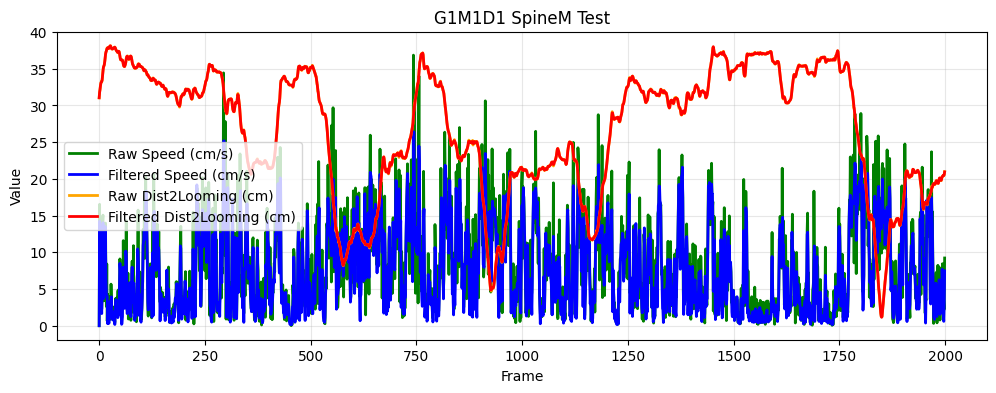

In [ ]:
from analyze_data_3d_utils.DataVisualizer import plot_lines

# # Calculate raw speed and dist2looming for comparison.
# raw_velocity_dict = {}
# raw_speed_dict = {}
# raw_dist2looming_dict = {}
# for sess_id, raw_coords in raw_coord_dict.items():  # coords: (n_frames, n_joints, 3)
#     n_joints = raw_coords.shape[1]
#     raw_velocity_dict[sess_id] = {}
#     raw_speed_dict[sess_id] = {}
#     raw_dist2looming_dict[sess_id] = {}
#     for joint_idx in range(n_joints):
#         joint_name = joint_names[joint_idx]
#         velocity, speed = calculate_speed(raw_coords, unit='cm/s', joint_idx=joint_idx, exclude_z=True)
#         _, dist2looming = calculate_distance(raw_coords, joint_idx=joint_idx, target_point=looming_center, exclude_z=True)
#         raw_velocity_dict[sess_id][joint_name] = velocity
#         raw_speed_dict[sess_id][joint_name] = speed
#         raw_dist2looming_dict[sess_id][joint_name] = dist2looming

# Draw speed and dist2looming line plot of all mice.
interest_joints = ['SpineM']
num_mice = len(raw_coord_dict)

for interest_joint in interest_joints:
    for sess_id in [list(raw_coord_dict.keys())[0]]:
        g = int(sess_id[1]) - 1
        # Draw test data for filtering check.
        draw_frames = (0, 2000)
        speed_series = speed_dict[sess_id][interest_joint][draw_frames[0]: draw_frames[1]]
        dist_series = dist2looming_dict[sess_id][interest_joint][draw_frames[0]: draw_frames[1]]
        raw_speed_series = raw_speed_dict[sess_id][interest_joint][draw_frames[0]: draw_frames[1]]
        raw_dist_series = raw_dist2looming_dict[sess_id][interest_joint][draw_frames[0]: draw_frames[1]]
        series_dict = {
            'Raw Speed (cm/s)': (raw_speed_series, 'green'), 
            'Filtered Speed (cm/s)': (speed_series, 'blue'), 
            'Raw Dist2Looming (cm)': (raw_dist_series, 'orange'), 
            'Filtered Dist2Looming (cm)': (dist_series, 'red'), 
        }
        title_id = f'{sess_id} {interest_joint} Test'
        plot_lines(series_dict, draw_frames, title_id)

In [ ]:
from analyze_data_3d_utils.DataVisualizer import plot_lines
from analyze_data_3d_utils.DataProcessor import smooth_data

# Looming parameters for different groups
blank_time_list = [0, 0.5, 1, 3, 0]  # seconds between looming stimuli
looming_rep_list = [5, 5, 5, 5, 1]   # number of looming repeats per trial
looming_duration = 0.75  # seconds

# Draw speed and dist2looming line plot of all mice.
interest_joint = 'SpineM'
num_mice = len(coord_dict)

for sess_id in lsf_dict.keys():
    # Determine group number from session ID (e.g., 'G1M1D1' -> group 1)
    g = int(sess_id.split('G')[1].split('M')[0])
    blank_time = blank_time_list[g - 1]
    looming_rep = looming_rep_list[g - 1]
    
    lsf_list = lsf_dict[sess_id]
    for t_id, lsf in enumerate(lsf_list):
        draw_frames = (lsf-fps*5, lsf+fps*60)
        print(sess_id, t_id, draw_frames)
        
        # Calculate all looming start frames for this trial
        lsf_list = []
        for i in range(looming_rep):
            loom_start = lsf + i * (looming_duration + blank_time) * fps
            lsf_list.append(loom_start)
        
        # Get raw data
        speed_array = speed_dict[sess_id][interest_joint]
        dist_array = dist2looming_dict[sess_id][interest_joint]
        
        # Apply smoothing (you can adjust method and parameters)
        smth_speed_array = smooth_data(speed_array, method='gaussian', sigma=2)
        smth_dist_array = smooth_data(dist_array, method='gaussian', sigma=2)
        
        data_dict = {
            'Speed (cm/s)': (smth_speed_array, 'blue'),
            'Distance to Looming (cm)': (smth_dist_array, 'red'),
        }
        title_id = f'{sess_id}T{t_id+1}_speed&dist2looming'
        xticks = np.arange(-5, 61, 5)
        save_dir = '/home/gxj/Desktop/gxj/code/lst_3d_code/speed&dist2looming'
        
        # Pass looming_starts to plot_lines (first element will be used as time reference)
        plot_lines(data_dict, draw_frames, title_id, xticks, save_dir, 
                   fps, lsf_list)

#### draw speed histogram.

<Figure size 1000x600 with 0 Axes>

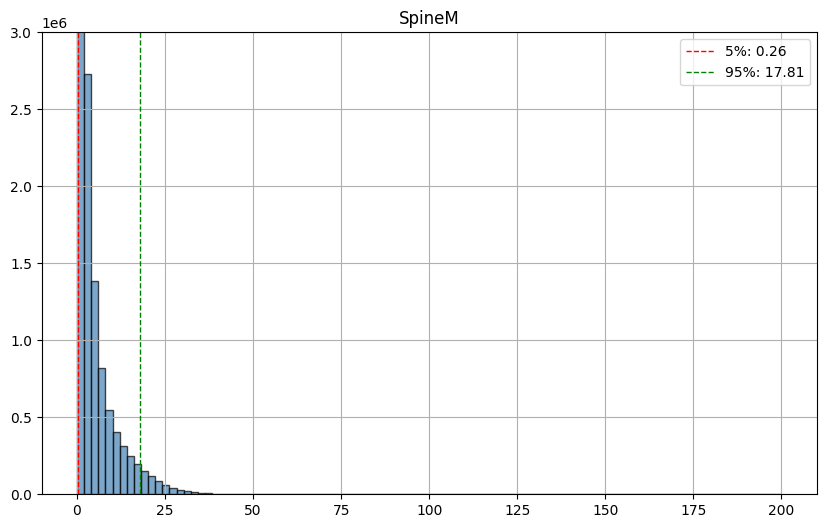

0.08772238098793035 0.26334626336524636 0.4625862498915207 12.728385348389036 17.81107447583212 28.768385947254586


In [44]:
import matplotlib.pyplot as plt

# Draw speed histogram to detect freezing and running.
for joint in ['SpineM']:
    all_speeds = []
    for sess_id in speed_dict:
        speed_series = speed_dict[sess_id][joint]
        all_speeds.append(speed_series)
    speeds = np.concatenate(all_speeds)

    plt.figure(figsize=(10, 6))
    p01 = np.quantile(speeds, 0.01)
    p05 = np.quantile(speeds, 0.05)
    p10 = np.quantile(speeds, 0.10)
    p90 = np.quantile(speeds, 0.90)
    p95 = np.quantile(speeds, 0.95)
    p99 = np.quantile(speeds, 0.99)
    plt.figure(figsize=(10, 6))
    plt.hist(speeds, bins=np.linspace(0, 200, 100), color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(p05, color='red', linestyle='--', linewidth=1, label=f'5%: {p05:.2f}')
    plt.axvline(p95, color='green', linestyle='--', linewidth=1, label=f'95%: {p95:.2f}',)
    plt.ylim(0, 3e6)
    plt.title(joint)
    plt.legend()
    plt.grid(True)
    plt.show()
print(p01, p05, p10, p90, p95, p99)

#### draw z-coord histogram.

<Figure size 1000x600 with 0 Axes>

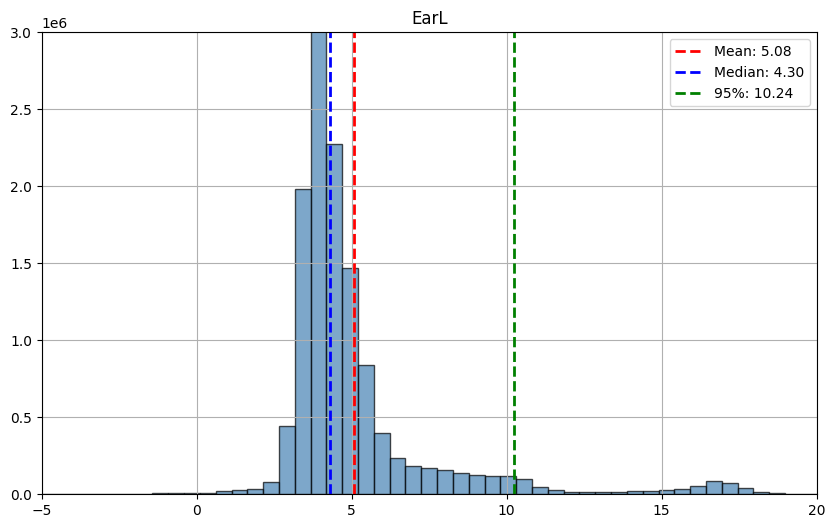

<Figure size 1000x600 with 0 Axes>

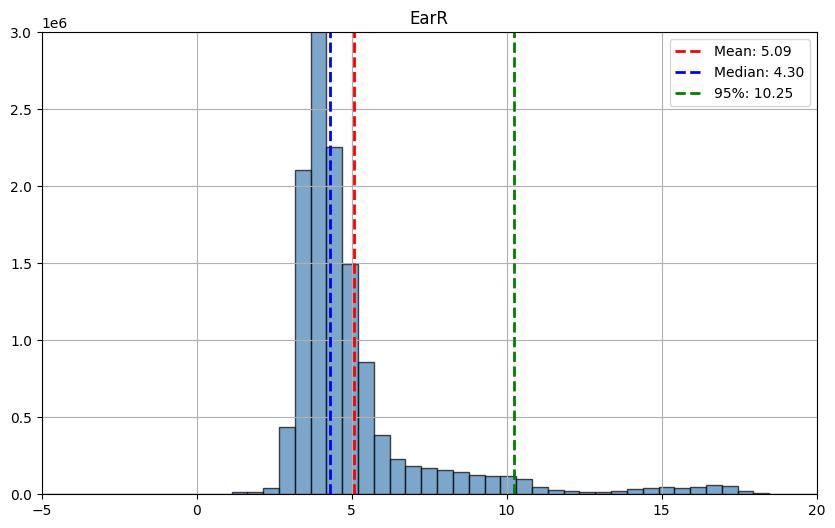

<Figure size 1000x600 with 0 Axes>

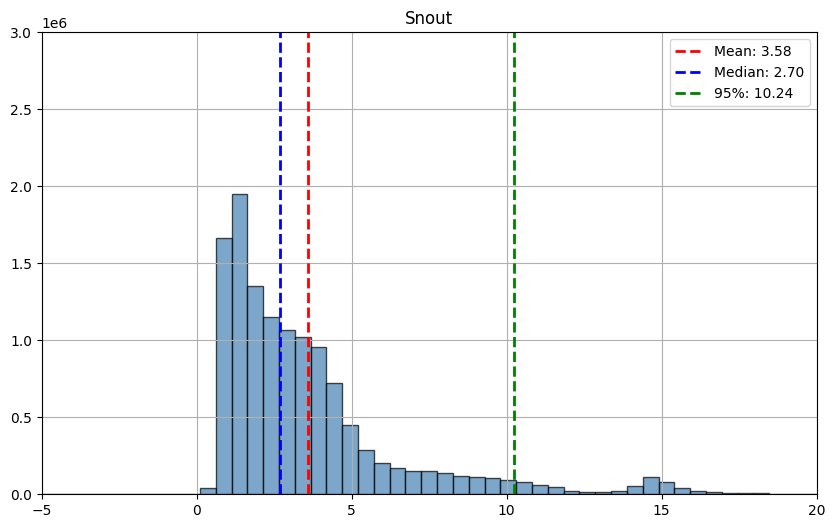

<Figure size 1000x600 with 0 Axes>

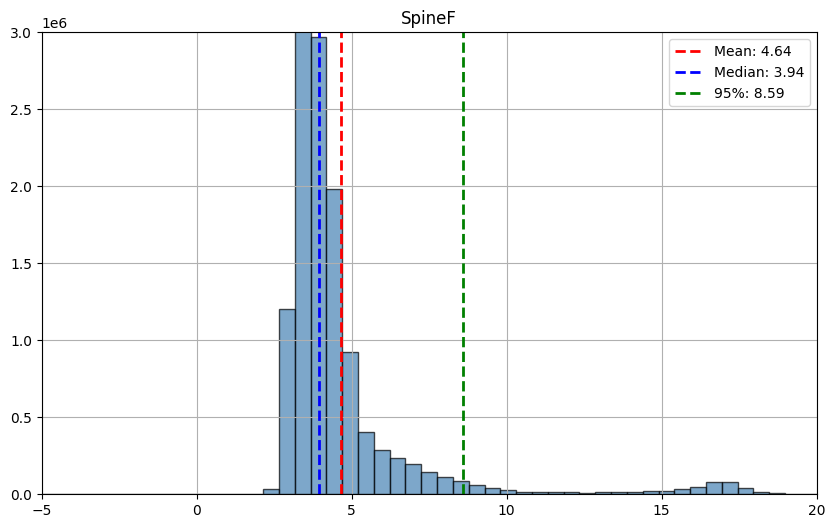

<Figure size 1000x600 with 0 Axes>

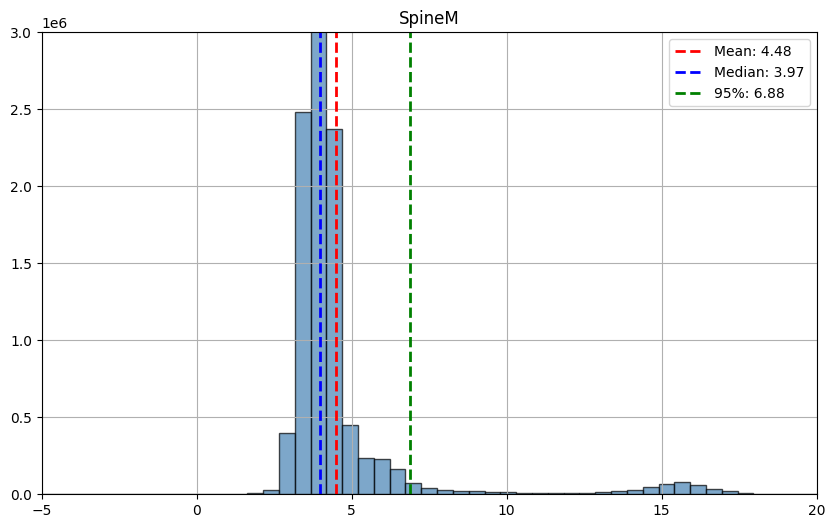

<Figure size 1000x600 with 0 Axes>

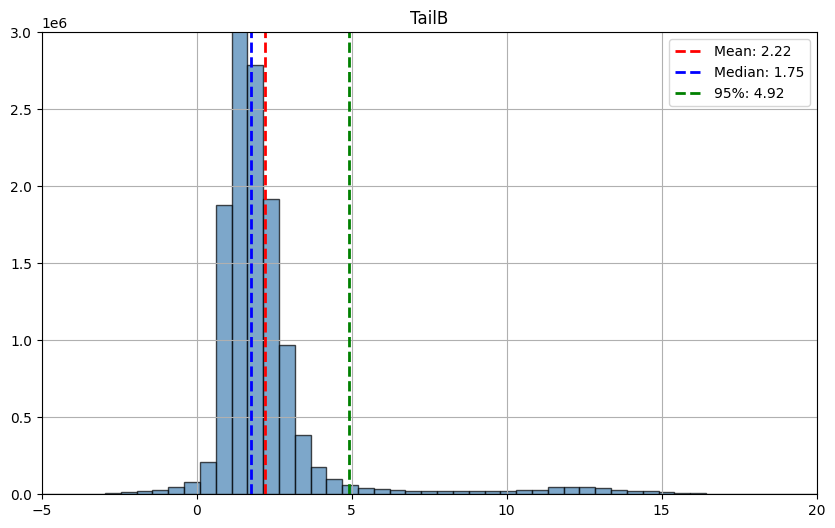

<Figure size 1000x600 with 0 Axes>

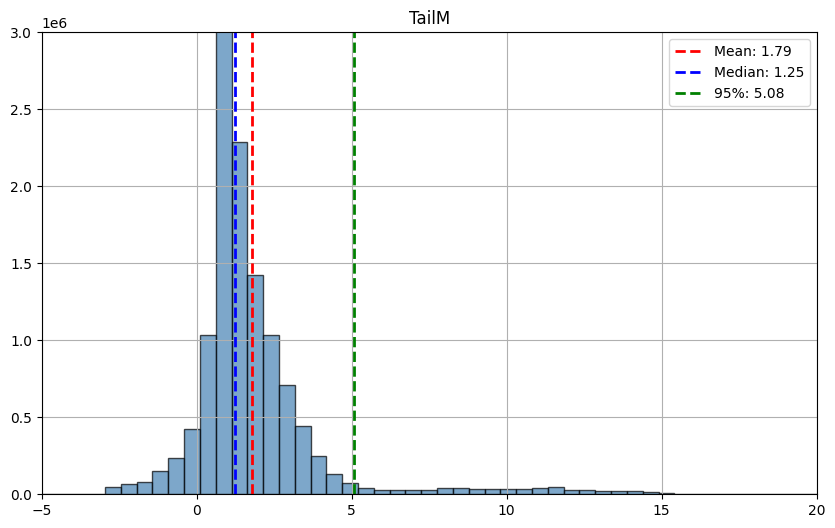

<Figure size 1000x600 with 0 Axes>

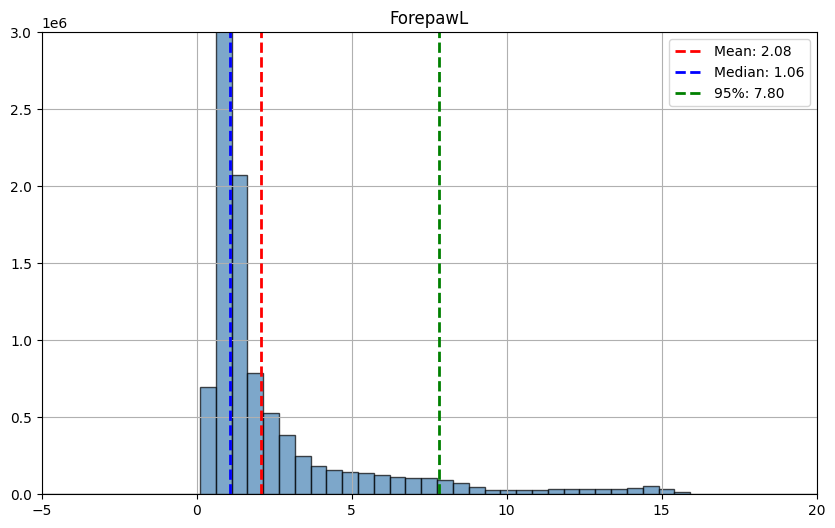

<Figure size 1000x600 with 0 Axes>

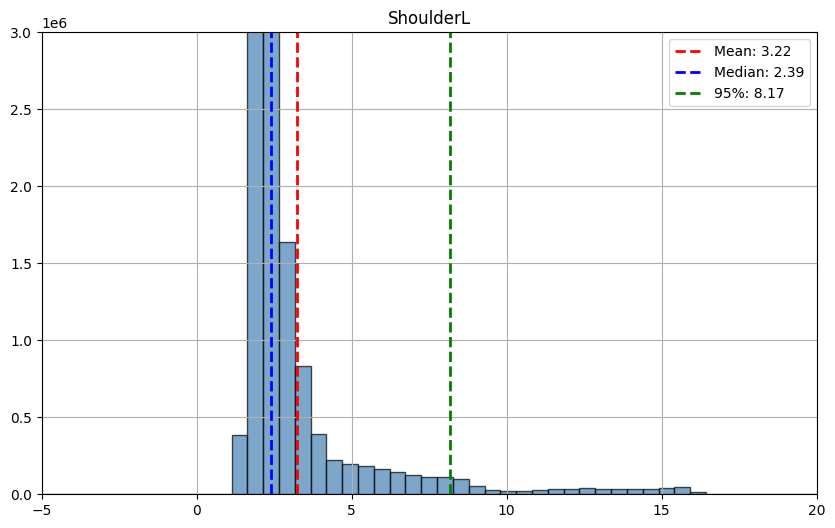

<Figure size 1000x600 with 0 Axes>

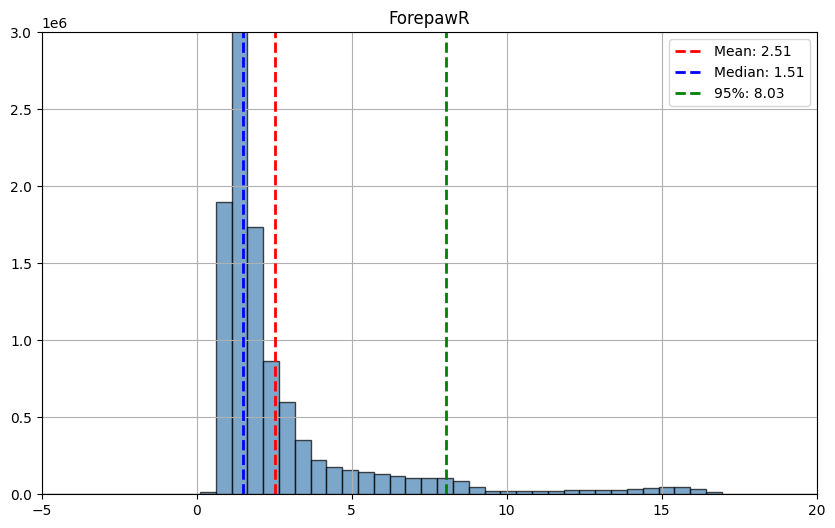

<Figure size 1000x600 with 0 Axes>

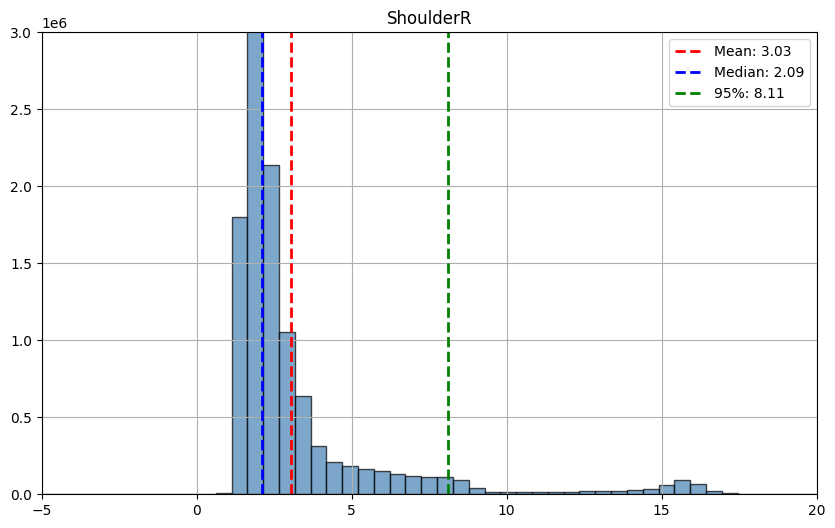

<Figure size 1000x600 with 0 Axes>

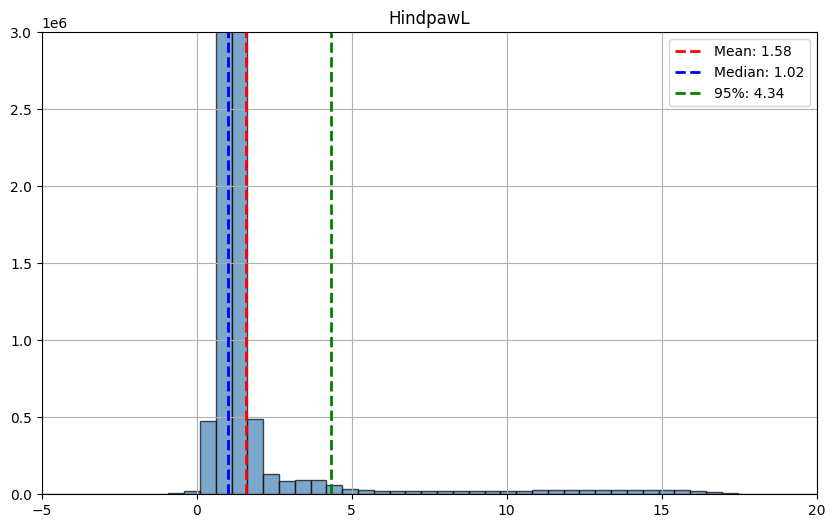

<Figure size 1000x600 with 0 Axes>

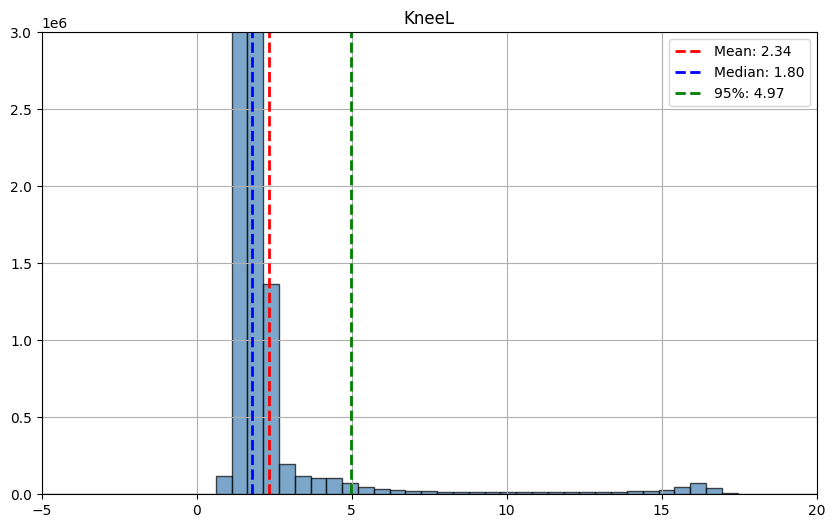

<Figure size 1000x600 with 0 Axes>

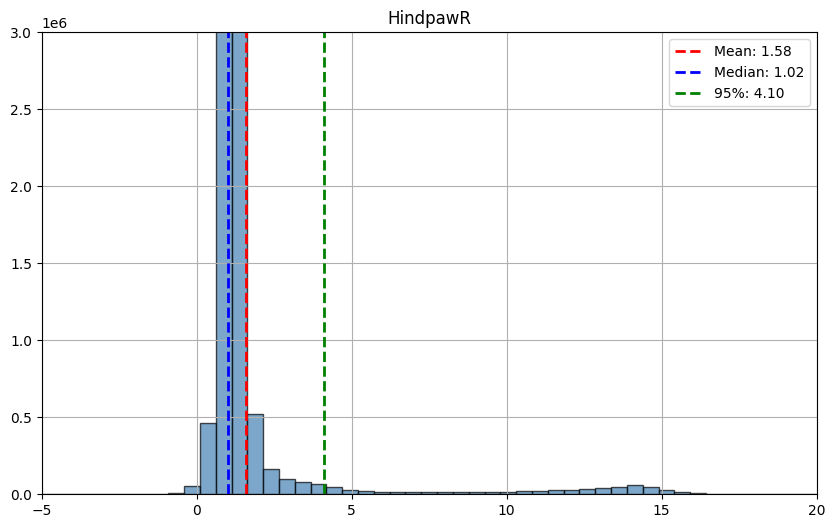

<Figure size 1000x600 with 0 Axes>

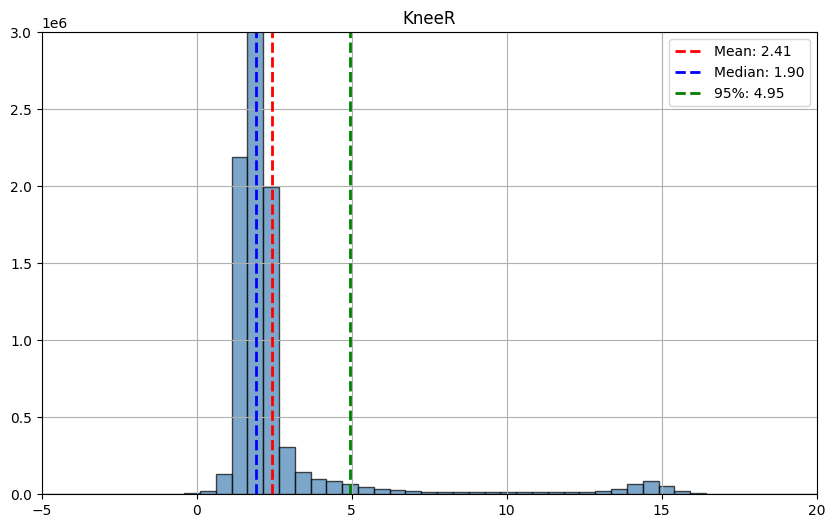

In [2]:
import matplotlib.pyplot as plt

# Draw z-coord histogram to detect rearing.
for joint in simp_joint_names:
    all_z_coords = []
    for m_id in coord_dict:
        spine_idx = simp_joint_names.index(joint)
        z_series = coord_dict[m_id][:, spine_idx, 2]
        all_z_coords.append(z_series)
    z_coords = np.concatenate(all_z_coords)

    plt.figure(figsize=(10, 6))
    z_mean = np.mean(z_coords)
    z_median = np.median(z_coords)
    p95 = np.quantile(z_coords, 0.95)
    plt.figure(figsize=(10, 6))
    plt.hist(z_coords, bins=np.linspace(-5, 20, 50), color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(z_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {z_mean:.2f}')
    plt.axvline(z_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {z_median:.2f}')
    plt.axvline(p95, color='green', linestyle='--', linewidth=2, label=f'95%: {p95:.2f}',)
    plt.xlim(-5, 20)
    plt.ylim(0, 3e6)
    plt.title(joint)
    plt.legend()
    plt.grid(True)
    plt.show()

#### draw histogram of behavior bout durations.

bout count: 919025
mean: 13.62 frames
median: 9.00 frames
max: 2823 frames
p05: 1.00 frames
p10: 2.00 frames


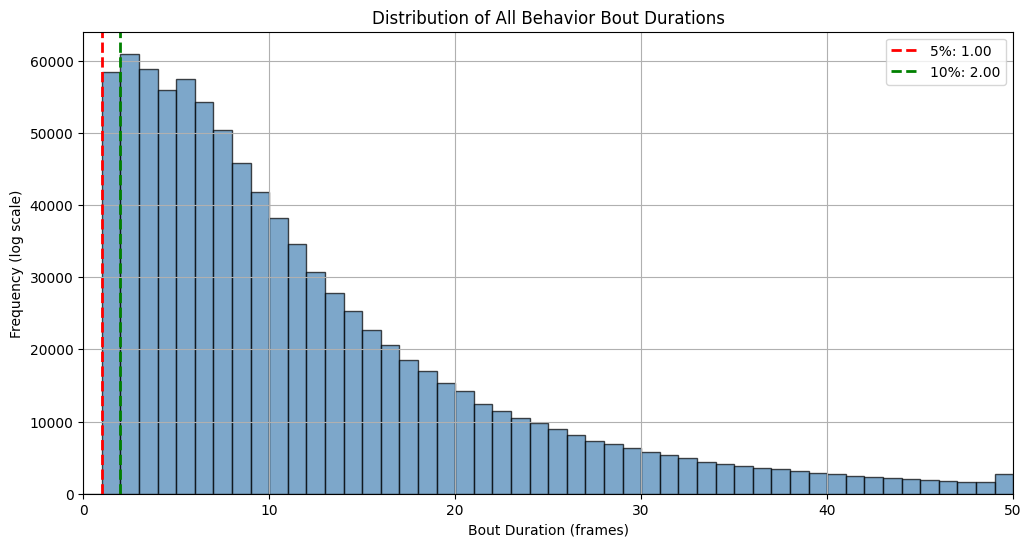

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from analyze_data_3d_utils.DataAnalyzer import calculate_behavior_bout_durations

mean_bhvr_durations_dict = calculate_behavior_bout_durations(bhvr_tuples_dict)

# Aggregate all bout durations into a single list for overall statistics and histogram.
all_bout_durations = []

for bhvr, durations_by_session in mean_bhvr_durations_dict.items():
    for sess_id, durations in durations_by_session.items():
        if durations is not None:
            if isinstance(durations, list):
                all_bout_durations.extend([d for d in durations if d is not None])
            else:
                all_bout_durations.append(durations)

all_bout_durations = np.array(all_bout_durations)

print(f"bout count: {len(all_bout_durations)}")
print(f"mean: {np.mean(all_bout_durations):.2f} frames")
print(f"median: {np.median(all_bout_durations):.2f} frames")
print(f"max: {np.max(all_bout_durations):.0f} frames")
p05 = np.quantile(all_bout_durations, 0.05)
print(f"p05: {p05:.2f} frames")
p10 = np.quantile(all_bout_durations, 0.10)
print(f"p10: {p10:.2f} frames")


# Draw histogram.
plt.figure(figsize=(12, 6))
bins = np.arange(0, 51, 1)
plt.hist(all_bout_durations, bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(p05, color='red', linestyle='--', linewidth=2, label=f'5%: {p05:.2f}')
plt.axvline(p10, color='green', linestyle='--', linewidth=2, label=f'10%: {p10:.2f}')
plt.xlabel('Bout Duration (frames)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of All Behavior Bout Durations')
plt.xlim(0, 50)
# plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

#### draw ethogram.

In [10]:
from analyze_data_3d_utils.DataVisualizer import plot_ethogram
from analyze_data_3d_utils.DataAnalyzer import filter_behavior_in_time_range, sync_start_time

bhvr_params = {
    'walking': ('lightgray', 1),
    'trotting': ('darkgray', 1), 
    'running': ('red', 1),

    'sniffing': ('violet', 1),

    'head_raising': ('gold', 1), 
    'incomplete_rearing': ('orange', 1), 
    'complete_rearing': ('darkorange', 1), 
    'rearing': ('darkorange', 1),

    'slightly_mobile': ('skyblue', 1), 
    'immobile': ('blue', 1), 

    'face_grooming': ('limegreen', 1), 
    'body_grooming': ('green', 1), 
    'genital_grooming': ('darkgreen', 1),

    'other': ('white', 1),
    'onnest': ('black', 1)
}


blank_time_list = [0, 0.5, 1, 3, 0]  # seconds between looming stimuli
looming_rep_list = [5, 5, 5, 5, 1]   # number of looming repeats per trial
looming_duration = 0.75  # seconds

# Plot ethogram for each session separately
for g in range(1, 6):
    for m in range(1, 16):
        for d in range(1, 6):
            sess_id = f'G{g}M{m}D{d}'
            if sess_id in lsf_dict:
                bhvr_etho_dict = {}
                nest_etho_dict = {}
                for t, lsf in enumerate(lsf_dict[sess_id]):
                    toi = (lsf - fps*5, lsf + fps*60)
                    bhvr_tuples_sess = filter_behavior_in_time_range({sess_id: bhvr_tuples_dict[sess_id]}, toi)
                    nest_tuples_sess = filter_behavior_in_time_range({sess_id: nest_tuples_dict[sess_id]}, toi)
                    sync_toi = (lsf, lsf + fps*60)
                    bhvr_tuples_sync = sync_start_time(bhvr_tuples_sess, sync_toi)
                    nest_tuples_sync = sync_start_time(nest_tuples_sess, sync_toi)
                    bhvr_etho_dict[f'{sess_id}T{t+1}'] = bhvr_tuples_sync[sess_id]
                    nest_etho_dict[f'{sess_id}T{t+1}'] = nest_tuples_sync[sess_id]
                    

                    # Calculate all looming start frames for this trial
                    blank_time = blank_time_list[g - 1]
                    looming_rep = looming_rep_list[g - 1]
                    lsf_list = []
                    for i in range(looming_rep):
                        loom_start = i * (looming_duration + blank_time) * fps
                        lsf_list.append(loom_start)
                # Plot ethogram for this session
                plot_ethogram(
                    bhvr_etho_dict, 
                    nest_etho_dict,
                    bhvr_params=bhvr_params, 
                    draw_frames=(-200, 1300),
                    lsf_list=lsf_list, 
                    title=f'ethogram_{sess_id}', 
                    save_dir='/home/gxj/Desktop/gxj/code/lst_3d_code/ethogram'
                )


Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M1D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M1D2.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M1D3.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M1D4.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M1D5.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M2D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M2D2.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M2D3.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M2D4.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M2D5.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M3D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M3D2.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G1M3D3.png
Saved: /home/gxj/Desktop/

/home/gxj/Desktop/gxj/code/lst_3d_code/analyze_data_3d_utils/DataVisualizer.py:178: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, trial_idx)


Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M3D5.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M4D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M4D2.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M4D3.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M4D4.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M4D5.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M5D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M5D2.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M5D3.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M5D4.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M5D5.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M6D1.png
Saved: /home/gxj/Desktop/gxj/code/lst_3d_code/ethogram/ethogram_G2M6D2.png
Saved: /home/gxj/Desktop/

#### decision-making analysis.

In [15]:
def calculate_all_looming_decisions(sess_id, bhvr_tuples_dict_sess, lsf_list, fps=20):
    """
    Calculate decisions for all looming stimuli across all trials in a session.
    
    Args:
        sess_id: str, session ID like 'G1M1D1'
        bhvr_tuples_dict_sess: dict, behavior tuples for the session 
                               {behavior_name: [(start, end), ...]}
        lsf_list: list of int, looming stimulus frame starts for each trial
        fps: int, frames per second
    
    Returns:
        dict with trial_id as key and decisions dict as value
        e.g., {'G1M1D1T1': {0: 'F', 1: 'E', ...}, 'G1M1D1T2': {...}, ...}
    """
    blank_time_list = [0, 0.5, 1, 3, 0]  # seconds
    looming_rep_list = [5, 5, 5, 5, 1]
    looming_duration = 0.75  # seconds

    # Extract g from session_id
    g = int(sess_id.split('G')[1].split('M')[0])
    
    blank_time = blank_time_list[g - 1]
    looming_rep = looming_rep_list[g - 1]
    
    # Define behavior categories
    freeze_behaviors = ['immobile', 'slightly_mobile']
    escape_behaviors = ['running']
    rear_behaviors = ['head_raising', 'incomplete_rearing', 'complete_rearing', 'rearing']
    
    all_trial_decisions = {}
    
    # Process each trial
    for t_idx, lsf in enumerate(lsf_list):
        trial_id = f'{sess_id}T{t_idx + 1}'
        decisions = []
        
        for looming_id in range(looming_rep):
            lsf_start = lsf + looming_id * (looming_duration + blank_time) * fps
            lsf_end = lsf_start + looming_duration * fps
            looming_end = lsf_end + blank_time * fps
            
            # Check which behaviors occur during this looming period
            has_freeze = False
            has_escape = False
            has_rear = False
            
            for bhvr_name, bhvr_list in bhvr_tuples_dict_sess.items():
                for start_frame, end_frame in bhvr_list:
                    # Check if behavior overlaps with looming period [lsf_start, looming_end]
                    if start_frame < looming_end and end_frame > lsf_start:
                        if any(bhvr_name.startswith(b) for b in freeze_behaviors):
                            has_freeze = True
                        elif any(bhvr_name.startswith(b) for b in escape_behaviors):
                            has_escape = True
                        elif any(bhvr_name.startswith(b) for b in rear_behaviors):
                            has_rear = True
            
            # Determine decision based on behavior combination
            # Priority: if all three -> F+E (most urgent response)
            # Otherwise check all possible combinations
            if has_escape and has_freeze and has_rear:
                decision = 'F+E'  # Most urgent, prioritize escape with freeze
            elif has_escape and has_freeze:
                decision = 'F+E'
            elif has_escape and has_rear:
                decision = 'R+E'
            elif has_freeze and has_rear:
                decision = 'F+R'
            elif has_escape:
                decision = 'E'
            elif has_freeze:
                decision = 'F'
            elif has_rear:
                decision = 'R'
            else:
                decision = 'I'
            
            decisions.append(decision)
        
        all_trial_decisions[trial_id] = decisions
    
    return all_trial_decisions


deci_looming_dict = {}
for sess_id in lsf_dict.keys():
    result = calculate_all_looming_decisions(
        sess_id, 
        bhvr_tuples_dict[sess_id], 
        lsf_dict[sess_id]
    )
    deci_looming_dict[sess_id] = result

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from collections import defaultdict
from matplotlib.patches import Patch

# Visualize looming decisions as heatmaps, one figure per G-D (group-day)
# 7 decision types: E, F+E, R+E, F, F+R, R, I
decision_to_code = {
    'E': 0,
    'F+E': 1,
    'R+E': 2,
    'F': 3,
    'F+R': 4,
    'R': 5,
    'I': 6,
}
code_to_label = ['E', 'F+E', 'R+E', 'F', 'F+R', 'R', 'I']
colors = ['red', 'purple', 'orange', 'blue', 'lightblue', 'yellow', 'green']
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], cmap.N)
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', label=code_to_label[i]) for i in range(len(code_to_label))]

# Group trials by G and D
group_trials = defaultdict(list)
for sess_id, trials in deci_looming_dict.items():
    g = sess_id.split('M')[0].replace('G', '')  # e.g., G1M1D1 -> '1'
    d = sess_id.split('D')[1]                    # e.g., G1M1D1 -> '1'
    group_key = f"G{g}D{d}"
    for trial_id, decisions in trials.items():
        group_trials[group_key].append((trial_id, decisions))

for gd_key, gd_trials in sorted(group_trials.items(), key=lambda kv: (int(kv[0].split('D')[0].replace('G', '')), int(kv[0].split('D')[1]))):
    if len(gd_trials) == 0:
        continue

    rows = []
    row_labels = []
    max_looms = 0
    for trial_id, decisions in gd_trials:
        row_labels.append(trial_id)
        rows.append(decisions)
        max_looms = max(max_looms, len(decisions))

    if max_looms == 0:
        continue

    data = np.full((len(rows), max_looms), np.nan)
    for i, decs in enumerate(rows):
        for j, dec in enumerate(decs):
            data[i, j] = decision_to_code.get(dec, np.nan)

    masked_data = np.ma.masked_invalid(data)

    fig, ax = plt.subplots(figsize=(max(6, max_looms * 0.8), max(6, len(rows) * 0.35)))
    ax.imshow(masked_data, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(np.arange(max_looms))
    ax.set_xticklabels([f'L{j+1}' for j in range(max_looms)])
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Looming # within trial')
    ax.set_ylabel('Trial ID')
    ax.set_title(f'Looming Decisions Heatmap - {gd_key}')

    ax.legend(handles=legend_handles, title='Decision', bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.tight_layout()
    dec_save_dir='/home/gxj/Desktop/gxj/code/lst_3d_code/decision_heatmap'
    filepath = os.path.join(dec_save_dir, f'decision_heatmap_{gd_key}.png')
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()

In [17]:
def calculate_trial_decision(looming_decisions):
    """
    Calculate trial-level decision from a list of looming decisions.
    
    Decision logic:
    - Filter out all 'I' (ignore)
    - Check if the first decision contains escape (E) in combination:
      * If first decision is F+E or R+E -> A+E (acute escape with other behaviors)
    - Otherwise collect all basic decision components (E, F, R) from all looming decisions
    - Combine based on what appeared:
      * If E+F appeared -> F+E (gradual combination)
      * If E+R appeared -> R+E (gradual combination)
      * If F+R appeared (but no E) -> F+R
      * If only E -> E
      * If only F -> F
      * If only R -> R
    - If all decisions are 'I': trial decision is 'I'
    
    Args:
        looming_decisions: list of looming-level decisions ['E', 'F+E', 'R+E', 'F', 'F+R', 'R', 'I']
    
    Returns:
        str: trial-level decision from ['E', 'F+E', 'R+E', 'F', 'F+R', 'R', 'I', 'A+E']
    """
    # Filter out 'I' (ignore)
    filtered = [d for d in looming_decisions if d != 'I']
    
    # If all are 'I', return 'I'
    if len(filtered) == 0:
        return 'I'
    
    # Check if the first decision contains E in combination (acute response)
    first_decision = filtered[0]
    if first_decision in ['F+E', 'R+E']:
        # Acute escape response: first looming already triggered combined response with E
        return 'A+E'
    
    # Otherwise, track which basic decision types appeared in the trial
    has_E = False
    has_F = False
    has_R = False
    
    for dec in filtered:
        if 'E' in dec:
            has_E = True
        if 'F' in dec:
            has_F = True
        if 'R' in dec:
            has_R = True
    
    # Determine trial decision based on combination
    # Priority: E combinations first
    if has_E and has_F:
        return 'F+E'
    elif has_E and has_R:
        return 'R+E'
    elif has_F and has_R:
        return 'F+R'
    elif has_E:
        return 'E'
    elif has_F:
        return 'F'
    elif has_R:
        return 'R'
    else:
        return 'I'


# Calculate trial-level decisions for all sessions
deci_trial_dict = {}
for sess_id, trials in deci_looming_dict.items():
    deci_trial_dict[sess_id] = {}
    for trial_id, looming_decisions in trials.items():
        trial_decision = calculate_trial_decision(looming_decisions)
        deci_trial_dict[sess_id][trial_id] = trial_decision

# Print statistics
print("Trial-level decision summary:")
all_trial_decisions = []
for sess_id, trials in deci_trial_dict.items():
    for trial_id, decision in trials.items():
        all_trial_decisions.append(decision)

from collections import Counter

decision_counts = Counter(all_trial_decisions)

total_trials = len(all_trial_decisions)

print(f"\nTotal trials: {total_trials}")    

for decision, count in sorted(decision_counts.items()):
    percentage = count / total_trials * 100
    print(f"  {decision}: {count} ({percentage:.1f}%)")

Trial-level decision summary:

Total trials: 1258
  A+E: 64 (5.1%)
  E: 7 (0.6%)
  F: 59 (4.7%)
  F+E: 163 (13.0%)
  F+R: 627 (49.8%)
  I: 40 (3.2%)
  R: 258 (20.5%)
  R+E: 40 (3.2%)



Summary Table (Counts)
 G-D  Total  E  A+E  F+E  R+E  F  F+R  R  I
G1D1     63  0    1   20    3  5   24  7  3
G1D2     43  0    0   14    3  1   17  8  0
G1D3     63  1    0    7    3  4   31 16  1
G1D4     54  0    0    2    3  5   28 12  4
G1D5     48  1    2    2    4  1   18 19  1
G2D1     53  0    2   11    1  3   28  7  1
G2D2     30  0    0    4    2  1   14  9  0
G2D3     39  0    3    3    2  0   19 12  0
G2D4     40  1    2    2    3  1   22  9  0
G2D5     11  0    0    1    0  0    4  6  0
G3D1     83  0    7   14    4  3   36 18  1
G3D2     47  0    2    4    1  0   33  7  0
G3D3     67  0    4   10    2  0   34 17  0
G3D4     71  0    4    3    2  2   33 27  0
G3D5     62  0    1    2    2  0   43 14  0
G4D1    104  0   12   23    2  1   56 10  0
G4D2     80  0    2   14    0  0   60  4  0
G4D3     76  0   11   11    0  0   50  4  0
G4D4     55  0    5    8    3  0   23 16  0
G4D5     58  0    5    8    0  0   38  7  0
G5D1     36  1    1    0    0 13    3 10  8
G5D2    

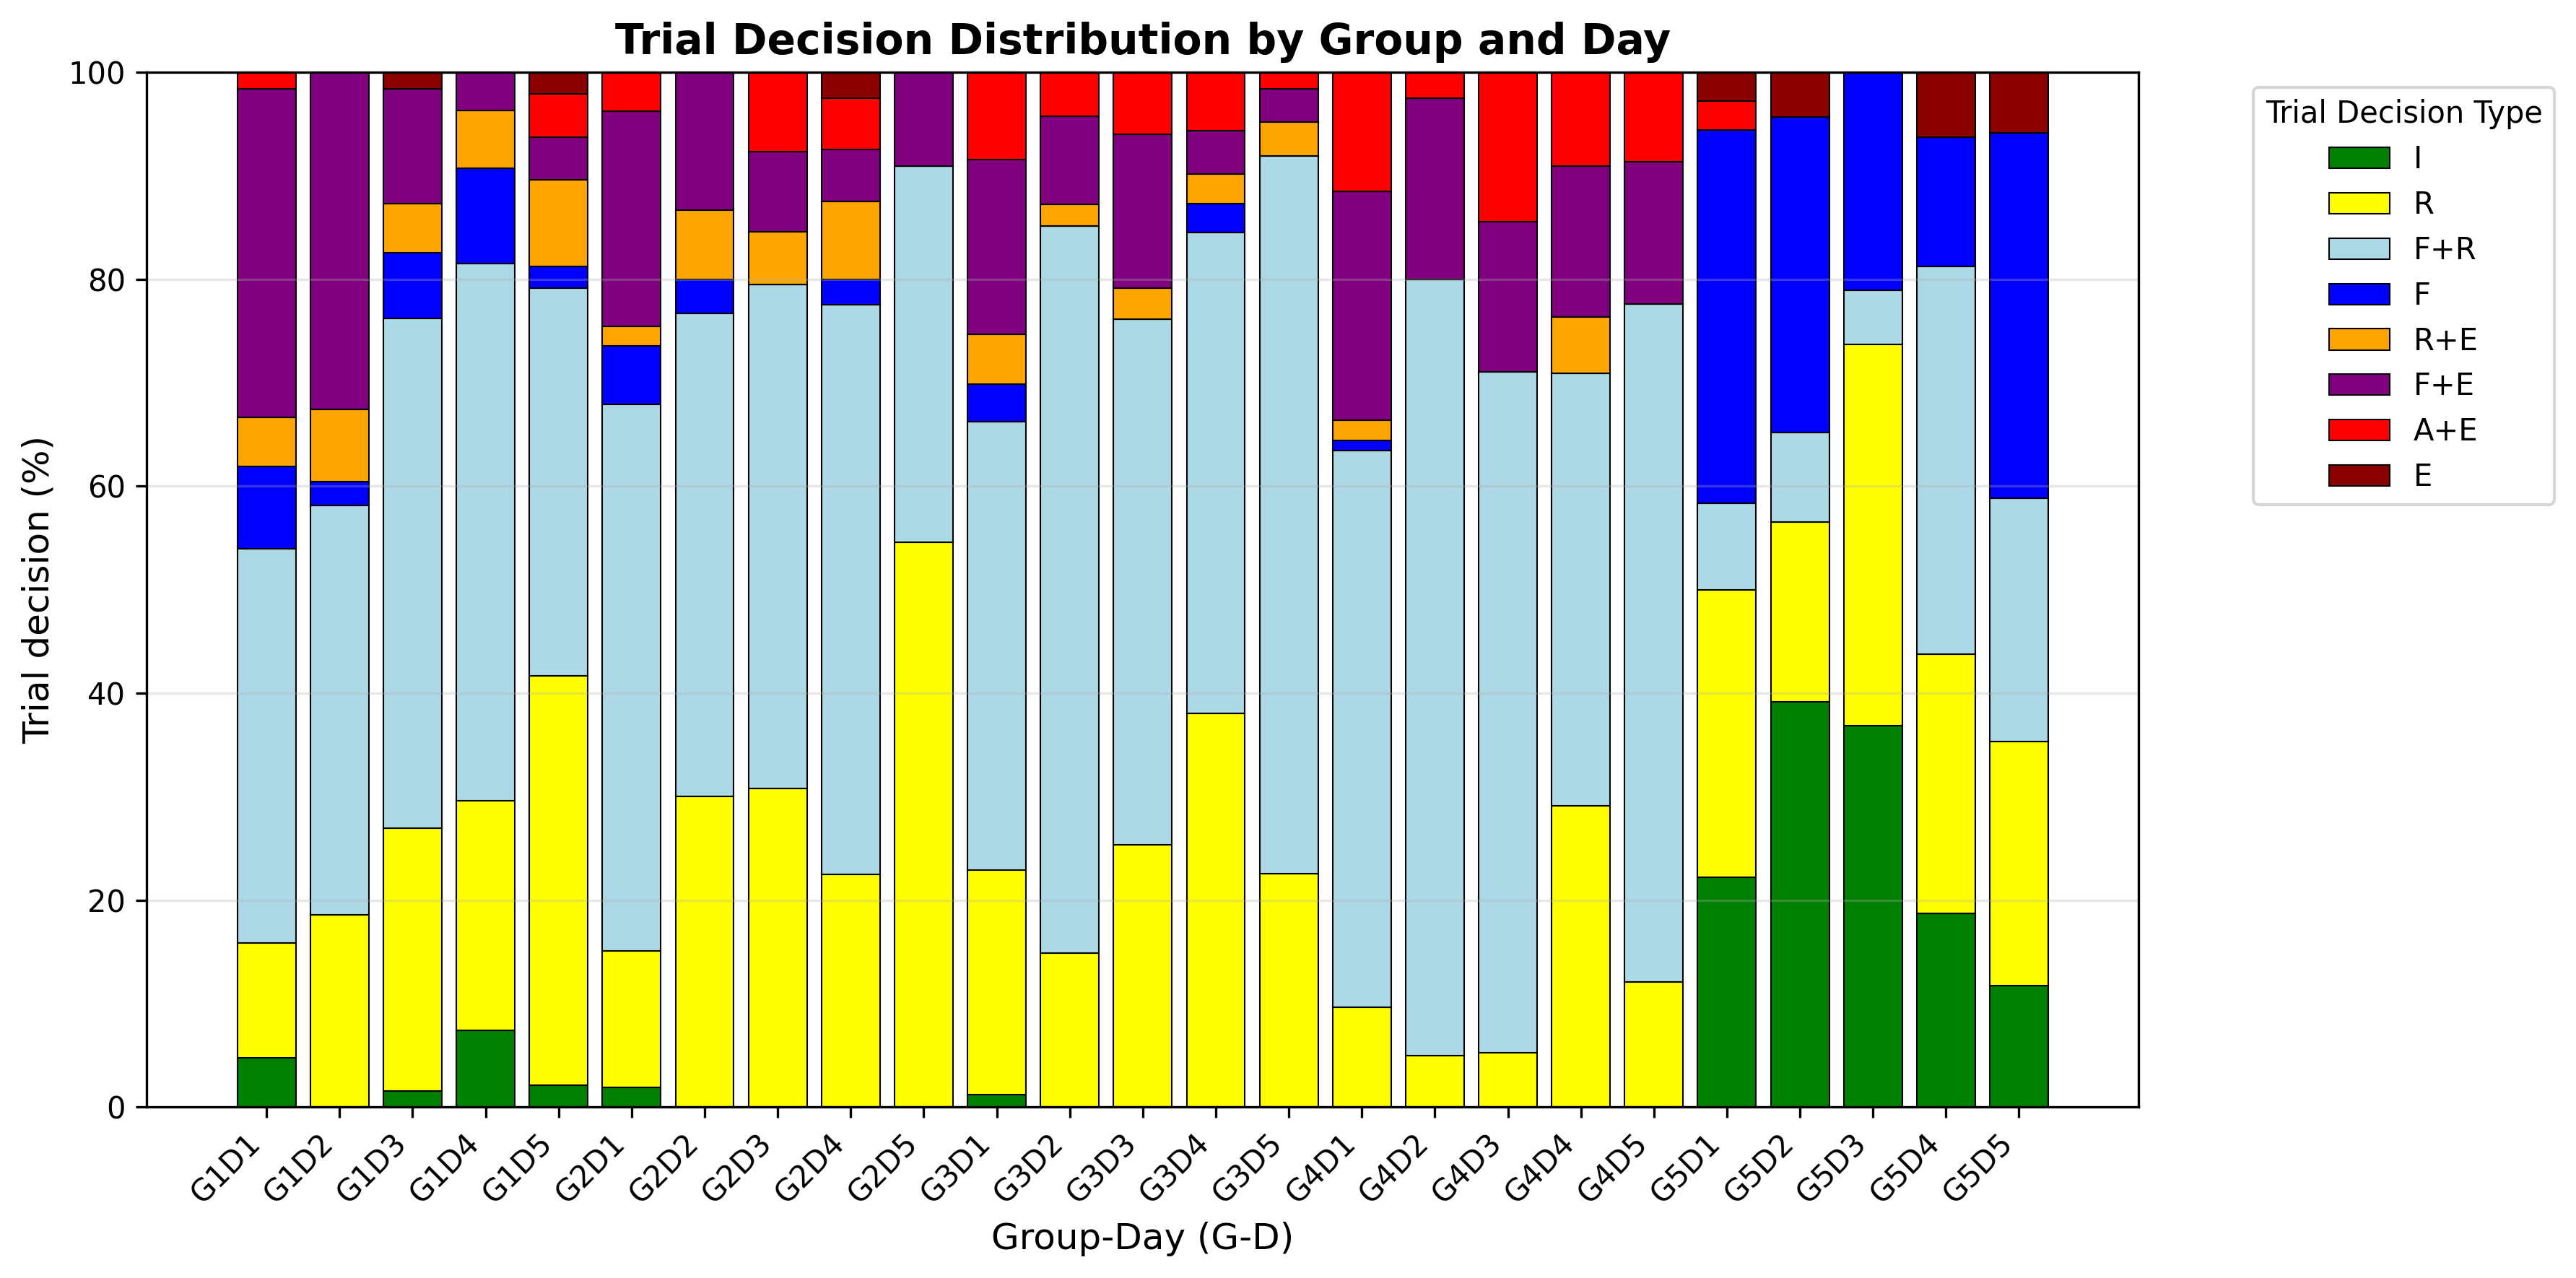

In [18]:
import pandas as pd
from collections import defaultdict, Counter

# Statistics for trial decisions by group (G) and day (D)
gd_trial_stats = defaultdict(lambda: [])

# Collect all trial decisions grouped by G and D
for sess_id, trials in deci_trial_dict.items():
    # Extract G and D from session_id (e.g., 'G1M1D1' -> g=1, d=1)
    g = int(sess_id.split('G')[1].split('M')[0])
    d = int(sess_id.split('D')[1])
    
    gd_key = f"G{g}D{d}"
    
    # Collect all trial decisions for this G-D combination
    for trial_id, decision in trials.items():
        gd_trial_stats[gd_key].append(decision)

# Calculate counts and proportions for each G-D combination
summary_data = []

for gd_key in sorted(gd_trial_stats.keys(), 
                      key=lambda x: (int(x.split('D')[0].replace('G', '')), 
                                   int(x.split('D')[1]))):
    decisions = gd_trial_stats[gd_key]
    total = len(decisions)
    decision_counts = Counter(decisions)
    
    # Possible decision types (8 types, including A+E for acute escape)
    decision_types = ['E', 'A+E', 'F+E', 'R+E', 'F', 'F+R', 'R', 'I']
    
    row_data = {'G-D': gd_key, 'Total': total}
    
    for dec_type in decision_types:
        count = decision_counts.get(dec_type, 0)
        percentage = (count / total * 100) if total > 0 else 0
        row_data[dec_type] = count
        row_data[f"{dec_type}_%"] = percentage
    
    summary_data.append(row_data)

# Create a summary DataFrame
df_summary = pd.DataFrame(summary_data)

# Reorder columns
count_cols = ['G-D', 'Total'] + [dec for dec in decision_types if dec in df_summary.columns]
pct_cols = [f"{dec}_%" for dec in decision_types if f"{dec}_%" in df_summary.columns]

# Display summary table
print("\n" + "=" * 80)
print("Summary Table (Counts)")
print("=" * 80)
print(df_summary[count_cols].to_string(index=False))

print("\n" + "=" * 80)
print("Summary Table (Percentages)")
print("=" * 80)
percentage_df = df_summary[['G-D', 'Total'] + pct_cols]
print(percentage_df.to_string(index=False))

# Create stacked bar plot for percentages
import matplotlib.pyplot as plt

# Define decision types and colors (same order as in statistics)
decision_types = ['E', 'A+E', 'F+E', 'R+E', 'F', 'F+R', 'R', 'I']
decision_colors = {
    'E': 'darkred',
    'A+E': 'red',
    'F+E': 'purple',
    'R+E': 'orange',
    'F': 'blue',
    'F+R': 'lightblue',
    'R': 'yellow',
    'I': 'green'
}

# Prepare data for stacking
gd_labels = percentage_df['G-D'].values
plot_data = {}
for dec in decision_types[::-1]:
    col_name = f"{dec}_%"
    if col_name in percentage_df.columns:
        plot_data[dec] = percentage_df[col_name].values
    else:
        plot_data[dec] = np.zeros(len(gd_labels))

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Starting position for stacking
bottom = np.zeros(len(gd_labels))

# Plot each decision type as a stacked bar
for dec in decision_types[::-1]:
    values = plot_data[dec]
    ax.bar(gd_labels, values, bottom=bottom, label=dec, 
           color=decision_colors[dec], edgecolor='black', linewidth=0.5)
    bottom += values

# Customize plot
ax.set_xlabel('Group-Day (G-D)', fontsize=12)
ax.set_ylabel('Trial decision (%)', fontsize=12)
ax.set_title('Trial Decision Distribution by Group and Day', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(title='Trial Decision Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## TODO: Modelling

#### decision-making HMM modelling

In [31]:
# Prepare observation sequences for HMM training
from analyze_data_3d_utils.DataAnalyzer import calculate_speed, calculate_angles, calculate_distance
from sklearn.preprocessing import LabelEncoder
from collections import Counter

def simplify_behaviors(bhvr_dict):
    """
    将15种细粒度行为合并为4个主要决策类别
    
    根据实际行为数据映射：
    - freeze: immobile, slightly_mobile (冻结/静止)
    - escape: running (逃跑)
    - rear: head_raising, incomplete_rearing, complete_rearing, rearing (后肢站立)
    - other: 其他所有行为 (探索、理毛、行走等日常行为)
    
    Args:
        bhvr_dict: 原始行为字典 {sess_id: behavior_array}
        
    Returns:
        simplified_bhvr_dict: 简化后的行为字典 {sess_id: simplified_array}
    """
    # 定义行为合并规则（基于实际的15种行为）
    merge_mapping = {
        # Freeze类别：静止不动
        'immobile': 'freeze',
        'slightly_mobile': 'freeze',
        
        # Escape类别：快速逃跑
        'running': 'escape',
        
        # Rear类别：所有与后肢站立相关的行为
        'head_raising': 'rear',
        'incomplete_rearing': 'rear',
        'complete_rearing': 'rear',
        'rearing': 'rear',
        
        # Other类别：其他所有行为（探索、理毛、行走等）
        'face_grooming': 'other',
        'body_grooming': 'other',
        'genital_grooming': 'other',
        'walking': 'other',
        'trotting': 'other',
        'sniffing': 'other',
        'onnest': 'other',
        'other': 'other',
    }
    
    print("Simplifying 15 behaviors to 4 decision categories...")
    print("Mapping rules:")
    print("  freeze ← immobile, slightly_mobile")
    print("  escape ← running")
    print("  rear   ← head_raising, incomplete_rearing, complete_rearing, rearing")
    print("  other  ← all other behaviors (grooming, walking, sniffing, etc.)")
    
    simplified_bhvr_dict = {}
    all_original_behaviors = set()
    all_simplified_behaviors = set()
    unmapped_behaviors = set()
    
    for sess_id, bhvr_array in bhvr_dict.items():
        # 确保是numpy数组
        if hasattr(bhvr_array, 'values'):
            bhvr_array = bhvr_array.values
        
        # 收集原始行为
        all_original_behaviors.update(bhvr_array)
        
        # 映射行为
        simplified_array = []
        for b in bhvr_array:
            b_str = b.lower() if isinstance(b, str) else str(b)
            if b_str in merge_mapping:
                simplified_array.append(merge_mapping[b_str])
            else:
                simplified_array.append('other')  # 默认归类为other
                unmapped_behaviors.add(b)
        
        simplified_bhvr_dict[sess_id] = np.array(simplified_array)
        all_simplified_behaviors.update(simplified_array)
    
    print(f"\n{'='*60}")
    print("Behavior simplification summary:")
    print(f"  Original behaviors: {len(all_original_behaviors)} types")
    print(f"    {sorted(all_original_behaviors)}")
    print(f"  Simplified to: {len(all_simplified_behaviors)} categories")
    print(f"    {sorted(all_simplified_behaviors)}")
    
    if unmapped_behaviors:
        print(f"\n  ⚠ Unmapped behaviors (assigned to 'other'): {sorted(unmapped_behaviors)}")
    
    # 统计每个类别的帧数
    print(f"\nCategory breakdown:")
    for category in ['freeze', 'escape', 'rear', 'other']:
        if category in all_simplified_behaviors:
            category_count = sum([np.sum(arr == category) for arr in simplified_bhvr_dict.values()])
            total_frames = sum([len(arr) for arr in simplified_bhvr_dict.values()])
            percentage = category_count / total_frames * 100
            print(f"  {category.upper():8s}: {category_count:,} frames ({percentage:.2f}%)")
    print(f"{'='*60}")
    
    return simplified_bhvr_dict


def prepare_observation_sequences(coord_dict, bhvr_dict, nest_dict, view_dict, lsf_dict, 
                                   joint_names, fps=20):
    """
    准备HMM训练的观测序列
    
    整合特征提取和数据格式化：
    1. 为每个session提取HMM所需的特征
    2. 将特征编码成数值格式
    3. 计算归一化统计量
    
    Args:
        coord_dict: 坐标数据字典 {sess_id: coords}
        bhvr_dict: 行为标签字典 {sess_id: labels} (应已简化为4个类别)
        nest_dict: nest区域标记字典 {sess_id: nest_series}
        view_dict: looming可见性字典 {sess_id: view_series}
        lsf_dict: looming起始帧字典 {sess_id: lsf_array}
        joint_names: 关节名称列表
        fps: 帧率
        
    Returns:
        all_observations: 观测序列列表
        behavior_encoder: 行为标签编码器
        feature_stats: 特征统计信息
    """
    
    # ===== 辅助函数 =====
    def _extract_session_features(sess_id, coord_sess, bhvr_sess, nest_sess, view_sess, lsf_sess,
                                   looming_duration, blank_time, looming_rep):
        """为单个session提取特征"""
        n_frames = coord_sess.shape[0]
        
        # 确保bhvr_sess是numpy数组
        if hasattr(bhvr_sess, 'values'):
            bhvr_sess = bhvr_sess.values
        
        # 使用SpineM作为代表点
        spine_idx = joint_names.index('SpineM') if 'SpineM' in joint_names else 0
        
        # 计算速度
        vel_sess, speed_sess = calculate_speed(coord_sess, fps=fps, unit='cm/s', joint_idx=spine_idx)
        speeds = speed_sess.flatten()
        vels_2d = vel_sess[:, 0, :2]  # 2D运动方向
        
        # 定义nest和looming中心
        nest_coord = np.array([[0, 0], [0, 22.65], [16.23, 22.65], [16.23, 0]])
        nest_center = nest_coord.mean(axis=0)
        looming_center = np.array([25.0, 50.0 - 14.25])
        
        # 计算距离
        _, dist2looming = calculate_distance(
            coord_sess, joint_idx=spine_idx, target_point=looming_center, exclude_z=True
        )
        dist2looming = dist2looming.flatten()  # 确保是1D数组
        
        _, dist2nest = calculate_distance(
            coord_sess, joint_idx=spine_idx, target_point=nest_center, exclude_z=True
        )
        dist2nest = dist2nest.flatten()  # 确保是1D数组
        
        # 计算运动方向与目标方向的夹角
        direction2looming = looming_center - coord_sess[:, spine_idx, :2]
        direction2nest = nest_center - coord_sess[:, spine_idx, :2]
        
        angle2looming = np.zeros(n_frames)
        angle2nest = np.zeros(n_frames)
        for i in range(1, n_frames):
            if speeds[i] > 0.1:  # 运动时才计算角度
                angle2looming[i] = calculate_angles(vels_2d[i:i+1], direction2looming[i])[0]
                angle2nest[i] = calculate_angles(vels_2d[i:i+1], direction2nest[i])[0]
            else:
                angle2looming[i] = angle2looming[i-1]
                angle2nest[i] = angle2nest[i-1]
        
        # 二值特征
        in_nest = (nest_sess['nest'] == 1).astype(int).values  # 确保是numpy数组
        looming_in_view = (view_sess[list(view_sess.keys())[0]] == 1).astype(int).values  # 确保是numpy数组
        
        # 按trial和looming切分特征
        sess_features = {}
        for t_idx, lsf in enumerate(lsf_sess):
            trial_id = f'{sess_id}T{t_idx + 1}'
            sess_features[trial_id] = {}
            
            for looming_id in range(looming_rep):
                lsf_start = int(lsf + looming_id * (looming_duration + blank_time) * fps)
                lsf_end = int(lsf_start + looming_duration * fps)
                looming_end = int(lsf_end + blank_time * fps)
                
                if looming_end <= n_frames:
                    sess_features[trial_id][looming_id] = {
                        'behavior': bhvr_sess[lsf_start:looming_end],
                        'speed': speeds[lsf_start:looming_end],
                        'angle2looming': angle2looming[lsf_start:looming_end],
                        'angle2nest': angle2nest[lsf_start:looming_end],
                        'dist2nest': dist2nest[lsf_start:looming_end],
                        'dist2looming': dist2looming[lsf_start:looming_end],
                        'in_nest': in_nest[lsf_start:looming_end],
                        'looming_in_view': looming_in_view[lsf_start:looming_end],
                    }
        
        return sess_features
    
    # ===== 主流程 =====
    print("Extracting HMM features for all sessions...")
    
    # 定义每组的looming参数
    looming_duration = 0.75  # 固定值，所有session相同
    blank_time_list = [0, 0.5, 1, 3, 0]  # G1-G5的blank_time
    looming_rep_list = [5, 5, 5, 5, 1]   # G1-G5的looming_rep
    
    all_features = {}
    
    for sess_id in lsf_dict.keys():
        # 根据sess_id确定使用哪组参数
        # 假设sess_id格式为 "G1_...", "G2_...", 等
        group_idx = int(sess_id[1]) - 1  # G1->0, G2->1, ..., G5->4
        blank_time = blank_time_list[group_idx]
        looming_rep = looming_rep_list[group_idx]
        
        print(f"  Processing {sess_id} (blank_time={blank_time}s, looming_rep={looming_rep})...")
        
        all_features[sess_id] = _extract_session_features(
            sess_id,
            coord_dict[sess_id],
            bhvr_dict[sess_id],
            nest_dict[sess_id],
            view_dict[sess_id],
            lsf_dict[sess_id],
            looming_duration=looming_duration,
            blank_time=blank_time,
            looming_rep=looming_rep
        )
    
    print(f"Feature extraction completed for {len(all_features)} sessions\n")
    
    # ===== 编码和格式化 =====
    print("Encoding and formatting observation sequences...")
    
    # 收集所有行为标签用于编码
    all_behaviors = set()
    for sess_id, trials in all_features.items():
        for trial_id, loomings in trials.items():
            for looming_id, features in loomings.items():
                all_behaviors.update(features['behavior'])
    
    behavior_encoder = LabelEncoder()
    behavior_encoder.fit(list(all_behaviors))
    
    # 构建观测序列并收集统计量
    all_observations = []
    feature_arrays = {
        'speed': [], 'angle': [], 'dist_nest': [], 'dist_looming': [],
        'in_nest': [], 'looming_in_view': [], 'behavior': []
    }
    
    for sess_id, trials in all_features.items():
        for trial_id, loomings in trials.items():
            for looming_id, features in loomings.items():
                # 编码行为
                behavior_codes = behavior_encoder.transform(features['behavior']).reshape(-1, 1)
                
                # 堆叠所有特征
                obs = np.column_stack([
                    behavior_codes,
                    features['speed'].reshape(-1, 1),
                    features['angle2looming'].reshape(-1, 1),
                    features['dist2nest'].reshape(-1, 1),
                    features['dist2looming'].reshape(-1, 1),
                    features['in_nest'].reshape(-1, 1),
                    features['looming_in_view'].reshape(-1, 1)
                ])
                
                all_observations.append(obs)
                
                # 收集统计量（连续型特征）
                feature_arrays['speed'].extend(features['speed'])
                feature_arrays['angle'].extend(features['angle2looming'])
                feature_arrays['dist_nest'].extend(features['dist2nest'])
                feature_arrays['dist_looming'].extend(features['dist2looming'])
                # 收集统计量（二值特征）
                feature_arrays['in_nest'].extend(features['in_nest'])
                feature_arrays['looming_in_view'].extend(features['looming_in_view'])
                # 收集行为标签
                feature_arrays['behavior'].extend(features['behavior'])
    
    # 计算特征统计量
    feature_stats = {
        # 连续型特征：均值 ± 标准差
        'speed_mean': np.mean(feature_arrays['speed']),
        'speed_std': np.std(feature_arrays['speed']),
        'angle_mean': np.mean(feature_arrays['angle']),
        'angle_std': np.std(feature_arrays['angle']),
        'dist_nest_mean': np.mean(feature_arrays['dist_nest']),
        'dist_nest_std': np.std(feature_arrays['dist_nest']),
        'dist_looming_mean': np.mean(feature_arrays['dist_looming']),
        'dist_looming_std': np.std(feature_arrays['dist_looming']),
        # 二值特征：比例
        'in_nest_ratio': np.mean(feature_arrays['in_nest']),
        'looming_visible_ratio': np.mean(feature_arrays['looming_in_view']),
        # 分类特征：分布
        'behavior_counts': dict(Counter(feature_arrays['behavior']))
    }
    
    print(f"Observation sequences prepared!")
    print(f"  Total sequences: {len(all_observations)}")
    print(f"  Behavior classes: {len(behavior_encoder.classes_)}")
    print(f"  Feature dimensions: 7")
    print(f"    [0] Behavior code")
    print(f"    [1] Speed (cm/s)")
    print(f"    [2] Angle to looming (rad)")
    print(f"    [3] Distance to nest (cm)")
    print(f"    [4] Distance to looming (cm)")
    print(f"    [5] In nest zone (0/1)")
    print(f"    [6] Looming visible (0/1)")
    
    return all_observations, behavior_encoder, feature_stats


# 准备HMM训练数据
print("="*60)
print("Step 1: Simplify behaviors from 15 to 4 categories")
print("="*60)
bhvr_kpms_dict_simplified = simplify_behaviors(bhvr_kpms_dict_smoothed)

print("\n" + "="*60)
print("Step 2: Extract features and prepare observation sequences")
print("="*60)
all_observations, behavior_encoder, feature_stats = prepare_observation_sequences(
    coord_dict,
    bhvr_kpms_dict_simplified,  # 使用简化后的行为数据
    nest_series_dict,
    trig_series_dict,
    lsf_dict,
    joint_names,
    fps=fps
)

print("\n" + "="*60)
print("Feature statistics:")
print(f"\nContinuous features (mean ± std):")
print(f"  Speed: {feature_stats['speed_mean']:.2f} ± {feature_stats['speed_std']:.2f} cm/s")
print(f"  Angle: {feature_stats['angle_mean']:.2f} ± {feature_stats['angle_std']:.2f} rad")
print(f"  Dist to nest: {feature_stats['dist_nest_mean']:.2f} ± {feature_stats['dist_nest_std']:.2f} cm")
print(f"  Dist to looming: {feature_stats['dist_looming_mean']:.2f} ± {feature_stats['dist_looming_std']:.2f} cm")
print(f"\nBinary features (proportion):")
print(f"  In nest: {feature_stats['in_nest_ratio']:.2%}")
print(f"  Looming visible: {feature_stats['looming_visible_ratio']:.2%}")
print(f"\nBehavior distribution:")
for bhvr, count in sorted(feature_stats['behavior_counts'].items()):
    print(f"  {bhvr}: {count} frames")

Step 1: Simplify behaviors from 15 to 4 categories
Simplifying 15 behaviors to 4 decision categories...
Mapping rules:
  freeze ← immobile, slightly_mobile
  escape ← running
  rear   ← head_raising, incomplete_rearing, complete_rearing, rearing
  other  ← all other behaviors (grooming, walking, sniffing, etc.)

Behavior simplification summary:
  Original behaviors: 15 types
    ['body_grooming', 'complete_rearing', 'face_grooming', 'genital_grooming', 'head_raising', 'immobile', 'incomplete_rearing', 'onnest', 'other', 'rearing', 'running', 'slightly_mobile', 'sniffing', 'trotting', 'walking']
  Simplified to: 4 categories
    ['escape', 'freeze', 'other', 'rear']

Category breakdown:
  FREEZE  : 1,070,774 frames (8.55%)
  ESCAPE  : 32,860 frames (0.26%)
  REAR    : 3,903,139 frames (31.17%)
  OTHER   : 7,514,639 frames (60.01%)

Step 2: Extract features and prepare observation sequences
Extracting HMM features for all sessions...
  Processing G1M1D1 (blank_time=0s, looming_rep=5)...


In [33]:
# Train HMM model
from hmmlearn import hmm
import pickle
import math

def train_hmm_decision_model(all_observations, n_states=4, n_iter=100, random_state=42):
    """
    训练HMM决策模型
    
    Args:
        all_observations: 观测序列列表，每个元素是一个(n_frames, 7)的数组
        n_states: 隐藏状态数量 (默认4: E, F, R, I)
        n_iter: EM迭代次数
        random_state: 随机种子
        
    Returns:
        model: 训练好的GaussianHMM模型
    """
    # 连接所有观测序列
    X = np.vstack(all_observations)
    lengths = [obs.shape[0] for obs in all_observations]
    
    print(f"Training data summary:")
    print(f"  Total frames: {X.shape[0]}")
    print(f"  Number of sequences: {len(lengths)}")
    print(f"  Average sequence length: {np.mean(lengths):.1f} ± {np.std(lengths):.1f} frames")
    print(f"  Sequence length range: [{min(lengths)}, {max(lengths)}]")
    print(f"\nFeature dimensions: {X.shape[1]}")
    print(f"  [0] Behavior code")
    print(f"  [1] Speed (cm/s)")
    print(f"  [2] Angle to looming (rad)")
    print(f"  [3] Distance to nest (cm)")
    print(f"  [4] Distance to looming (cm)")
    print(f"  [5] In nest zone (0/1)")
    print(f"  [6] Looming visible (0/1)")
    
    # 初始化并训练Gaussian HMM
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=n_iter,
        random_state=random_state,
        verbose=True
    )
    
    print(f"\nTraining HMM with {n_states} hidden states...")
    print("="*60)
    
    model.fit(X, lengths)
    
    print("="*60)
    print(f"Training completed!")
    print(f"  Log-likelihood: {model.score(X, lengths):.2f}")
    print(f"  Converged: {model.monitor_.converged}")
    print(f"\nModel parameters:")
    print(f"  Start probabilities shape: {model.startprob_.shape}")
    print(f"  Transition matrix shape: {model.transmat_.shape}")
    print(f"  Means shape: {model.means_.shape}")
    print(f"  Covariances shape: {model.covars_.shape}")
    
    return model


# 训练HMM模型
print("\n" + "="*60)
print("Training HMM Decision Model")
print("="*60)

base_decision_num = 4  # E, F, R, I
max_combine_num = 2
n_decision_states = base_decision_num + math.perm(base_decision_num, max_combine_num) - 3  # delete E start combinations (E+F, E+R, E+I)

hmm_decision_model = train_hmm_decision_model(
    all_observations, 
    n_states=n_decision_states, 
    n_iter=100,
    random_state=42
)

# 保存模型和编码器
print("\n" + "="*60)
print("Saving model and metadata...")

with open('hmm_decision_model.pkl', 'wb') as f:
    pickle.dump(hmm_decision_model, f)
with open('behavior_encoder.pkl', 'wb') as f:
    pickle.dump(behavior_encoder, f)
with open('feature_stats.pkl', 'wb') as f:
    pickle.dump(feature_stats, f)

print("Files saved successfully:")
print("  ✓ hmm_decision_model.pkl")
print("  ✓ behavior_encoder.pkl")
print("  ✓ feature_stats.pkl")
print(f"\nModel info:")
print(f"  States: {n_decision_states} (E, F, R, I)")
print(f"  Features: 7 (behavior + 6 continuous/binary features)")
print(f"  Training sequences: {len(all_observations)}")
print(f"  Behavior classes: {len(behavior_encoder.classes_)}")


Training HMM Decision Model
Training data summary:
  Total frames: 241240
  Number of sequences: 5846
  Average sequence length: 41.3 ± 24.2 frames
  Sequence length range: [15, 75]

Feature dimensions: 7
  [0] Behavior code
  [1] Speed (cm/s)
  [2] Angle to looming (rad)
  [3] Distance to nest (cm)
  [4] Distance to looming (cm)
  [5] In nest zone (0/1)
  [6] Looming visible (0/1)

Training HMM with 13 hidden states...


         1 -3345226.72137091             +nan
         2 -2641662.69130868 +703564.03006223
         3 -1031957.42344828 +1609705.26786040
         4 2738813.05406167 +3770770.47750995
         5  349996.99819099 -2388816.05587067
Model is not converging.  Current: 349996.998190994 is not greater than 2738813.0540616685. Delta is -2388816.0558706746


Training completed!
  Log-likelihood: 785091.15
  Converged: True

Model parameters:
  Start probabilities shape: (13,)
  Transition matrix shape: (13, 13)
  Means shape: (13, 7)
  Covariances shape: (13, 7, 7)

Saving model and metadata...
Files saved successfully:
  ✓ hmm_decision_model.pkl
  ✓ behavior_encoder.pkl
  ✓ feature_stats.pkl

Model info:
  States: 13 (E, F, R, I)
  Features: 7 (behavior + 6 continuous/binary features)
  Training sequences: 5846
  Behavior classes: 4


#### DDLI modelling

***Drifting Diffusion Leaky Integrator Model***

The animal's decision-making process in response to the looming stimulus during foraging is modeled as a drifting diffusion leaky integrator. An escape decision is initiated when the accumulated evidence level crosses a threshold.

---

***Evidence Accumulation Dynamics***

$$\frac{dx_i}{dt} = -\alpha \cdot x_i(t) + h_i \cdot \beta \cdot s(t) - r + \delta \cdot \frac{dW}{dt} \qquad (1)$$

$$E(t) = \mathcal{H}(x_i(t) - x_{thr}) \qquad (2)$$

where $x_i(t)$ is the evidence level to escape at time $t$ for $i$ th trial; $\alpha$ is the leaky component that drives the evidence level to zero and is the reciprocal of the time constant; $s(t)$ is the normalized diameter of the looming stimulus; $\beta$ is a free parameter that modulates the perceived threat value and is related to the stimulus contrast; $h_i$ is the habituation parameter; $r$ is the perceived reward value; $W(t)$ is a Wiener process, and $W(t + \Delta t) - W(t) \sim \mathcal{N}(0, \Delta t)$. $E(t)$ is the escape decision and $\mathcal{H}$ is the Heaviside step function.

---

***Habituation Function***

Because the animal exhibits rapid habituation to the looming stimulus for the first five trials, followed by a slower adaptation phase, the habituation effect is modeled as a sum of fast and slow components:

$$h_i = (e^{-tr_i/\tau_f} + e^{-tr_i/\tau_s})/2 \qquad (3)$$

where $tr_i$ is the $i$th trial, $\tau_f$ is the fast decay component, and $\tau_s$ is the slow decay component.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Parameters, Minimizer, report_fit

# DDLI Model with lmfit and dual thresholds (freezing, escape)
np.random.seed(42)

# Design
looming_duration = 0.5
n_loomings = 5

# Time
dt = 0.01
T = 30.0
# Start curves from -5s
t = np.arange(-5, T, dt)

# Initial defaults and thresholds
default_params = {
    'alpha': 0.20,
    'beta': 3.0,
    'r': 0.0,
    'delta': 0.3,
    'x0': 0.0,
    'tau_f': 2.0,
    'tau_s': 10.0,
}
# Dual thresholds
x_thr_freeze = 0.75
x_thr_escape = 1.0

# ISI set and targets (escape %)
ISI_conditions = [0.0, 0.5, 1.0, 3.0]
escape_targets = {0.0: 80.0, 0.5: 50.0, 1.0: 40.0, 3.0: 10.0}

# Stimulus (linear ramp)
def looming_stimulus(time_array, looming_times, duration=0.5):
    stim = np.zeros_like(time_array)
    for loom_t in looming_times:
        mask = (time_array >= loom_t) & (time_array < loom_t + duration)
        rel = np.where(mask, time_array - loom_t, 0)
        stim += mask * (rel / duration)
    return stim

# Habituation factor
def habituation_factor(past_times, current_time, tau_f, tau_s):
    if len(past_times) == 0:
        return 1.0
    diffs = current_time - np.array(past_times)
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 1.0
    h = np.mean([(np.exp(-d / tau_f) + np.exp(-d / tau_s)) / 2 for d in diffs])
    return np.clip(h, 0.0, 1.0)

# Single trial
def run_single_trial(looming_times, pars):
    alpha = pars['alpha']
    beta = pars['beta']
    r = pars['r']
    delta = pars['delta']
    x0 = pars['x0']
    tau_f = pars['tau_f']
    tau_s = pars['tau_s']

    stim = looming_stimulus(t, looming_times, looming_duration)
    x = np.zeros_like(t)
    xi = x0
    for i in range(len(t)):
        past_loomings = [lt for lt in looming_times if lt < t[i]]
        h_i = habituation_factor(past_loomings, t[i], tau_f, tau_s)
        dW = np.random.randn() * np.sqrt(dt)
        dx = -alpha * xi + h_i * beta * stim[i] - r + delta * dW
        xi = xi + dx * dt
        x[i] = xi
    return x

# Compute freezing/escape for a trial trace
def classify_trial(x_trace, looming_times):
    decision = {'freeze': np.zeros(len(looming_times), dtype=bool),
                'escape': np.zeros(len(looming_times), dtype=bool)}
    for idx, lt in enumerate(looming_times):
        window = (t >= lt) & (t < lt + 3.0)
        xw = x_trace[window]
        # escape if crossing escape threshold
        if np.any(xw >= x_thr_escape):
            decision['escape'][idx] = True
            continue
        # else freezing if crossing freezing threshold
        if np.any(xw >= x_thr_freeze):
            decision['freeze'][idx] = True
    return decision

# Simulate escape rate for an ISI
def simulate_escape_rate(ISI, pars, n_trials=100):
    looming_times = [3.0 + i * (looming_duration + ISI) for i in range(n_loomings)]
    escapes = np.zeros(n_loomings)
    for _ in range(n_trials):
        x_tr = run_single_trial(looming_times, pars)
        dec = classify_trial(x_tr, looming_times)
        escapes += dec['escape'].astype(int)
    return (escapes / n_trials) * 100.0

# lmfit parameters (global across ISIs)
params = Parameters()
params.add('alpha', value=default_params['alpha'], min=0.05, max=2.0)
params.add('beta', value=default_params['beta'], min=0.5, max=8.0)
params.add('r', value=default_params['r'], min=-0.5, max=0.5)
params.add('delta', value=default_params['delta'], min=0.05, max=1.0)
params.add('x0', value=default_params['x0'], min=-0.5, max=0.5)
params.add('tau_f', value=default_params['tau_f'], min=0.1, max=10.0)
params.add('tau_s', value=default_params['tau_s'], min=0.3, max=30.0)

# Residual: stack differences of escape rates across targeted ISIs

def residual(pars):
    p = {k: pars[k].value for k in pars.keys()}
    res_list = []
    for ISI in ISI_conditions:
        esc_rates = simulate_escape_rate(ISI, p, n_trials=60)
        # average escape across the 5 loomings for the condition
        esc_avg = esc_rates.mean()
        target = escape_targets[ISI]
        res_list.append(esc_avg - target)
    return np.array(res_list)

# Optimize
result = Minimizer(residual, params).minimize(method='least_squares')
fit_pars = {k: result.params[k].value for k in result.params.keys()}

print('=== Fit Report (escape probabilities across ISIs) ===')
report_fit(result)
print('Fitted parameters:')
for k, v in fit_pars.items():
    print(f'  {k}: {v:.4f}')




In [ ]:
# Plot combined evidence curves across ISIs (freeze & escape thresholds indicated)
fig, ax = plt.subplots(figsize=(8, 5))

for ISI in ISI_conditions:
    looming_times = [3.0 + i * (looming_duration + ISI) for i in range(n_loomings)]
    traces = []
    for _ in range(100):
        x_tr = run_single_trial(looming_times, fit_pars)
        traces.append(x_tr)
    traces = np.array(traces)
    mean_e = traces.mean(axis=0)
    sem_e = traces.std(axis=0, ddof=1) / np.sqrt(len(traces))

    ax.plot(t, mean_e, lw=2, label=f'ISI {ISI}s')
    ax.fill_between(t, mean_e - sem_e, mean_e + sem_e, alpha=0.18)

# Threshold lines
ax.axhline(0.6, color='blue', ls='--', lw=1.4, label='Freeze thr')
ax.axhline(1.4, color='red', ls='--', lw=1.4, label='Escape thr')

# Set requested x-axis range and ticks
ax.set_xlim(-5, 25)
ax.set_ylim(-0.5, 3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Evidence level')
ax.set_title('DDLI Model')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()